In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from bs4 import BeautifulSoup, NavigableString, Tag
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import requests
import threading

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from indoNLP.preprocessing import replace_slang
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import spacy

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

from tqdm import tqdm
import re
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta


## Configuration

In [242]:
kode_saham = "PADI"
kategori_saham = ['Pertambangan', 'Mineral', 'Energy', 'Energi', 'Sumber Daya Alam', 'SDA', 'migas', 'gas']
media_keywords = ['tribunnews', 'kompas', 'cnn', 'republika', 'tempo', 'detik', 'liputan6', 'okezone', 'tribunnewscom', 'kompascom', 'cnncom', 'republikacom', 'tempocom', 'detikcom', 'liputan6com', 'okezonecom', 'bisniscom']
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}
start = "2018-01-01"
end = datetime.now().strftime("%Y-%m-%d")
max_retries = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [243]:
def init_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ['enable-automation'])
    options.add_experimental_option("useAutomationExtension", False)
    options.add_argument("--disable-notifications")

    driver = webdriver.Chrome(options=options)
    return driver

def load_page(driver, element, max_retries = 10):
    for _ in range(max_retries):
        try:
            WebDriverWait(driver, 60).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, element))
            )
            break
        except TimeoutException:
            print("Refresh driver")
            driver.refresh()
            time.sleep(3)
    else:
        print("Gagal memuat halaman")
    
    time.sleep(2)
    html = driver.page_source
    
    return html

## Load Data Saham

In [244]:
df = yf.download(kode_saham+'.JK', start=start, end=end)
df.columns = df.columns.droplevel(1)
df.columns.name = None
df = df.reset_index()
df.to_csv(f"{kode_saham}.csv")
df

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2018-01-01,890.0,890.0,890.0,890.0,0
1,2018-01-02,870.0,915.0,825.0,890.0,104200
2,2018-01-03,820.0,900.0,820.0,900.0,31700
3,2018-01-04,795.0,850.0,780.0,800.0,181400
4,2018-01-05,805.0,820.0,795.0,795.0,56700
...,...,...,...,...,...,...
2065,2026-06-08,62.0,66.0,59.0,65.0,256458500
2066,2026-06-09,69.0,73.0,60.0,62.0,846572700
2067,2026-06-10,72.0,74.0,66.0,69.0,563171900
2068,2026-06-11,68.0,73.0,65.0,72.0,192338000


## Load Data IHSG

In [245]:
df_ihsg = yf.download('^JKSE', start=start, end=end)
df_ihsg.columns = df_ihsg.columns.droplevel(1)
df_ihsg.columns.name = None
df_ihsg = df_ihsg.reset_index()
df_ihsg.to_csv(f"IHSG.csv")

[*********************100%***********************]  1 of 1 completed


## Load Data Berita

In [246]:
news_national_keys = {'mata uang', 'kurs', 'rupiah', 'suku bunga', 'sbn', 'bi rate', 'bank indonesia', 'inflasi', 'BI 7-day RR', 'cadangan devisa'}
news_international_keys = {'dollar', 'dolar', 'fed', 'feds', 'the fed', 'the feds', 'USA', 'United State America', 'Amerika Serikat', 'Presiden Amerika Serikat', 'Federal Reserve', 'FOMC', 'US Dollar', 'USD', 'greenback', 'washington', 'white house', 'gedung putih', 'ECB', 'Bank of England', 'BOJ', 'Trump', 'MSCI', 'FTSE'}
company_international_keys = {kode_saham} | set(kategori_saham)

news_national_key_lower = [news_national_key.lower() for news_national_key in news_national_keys]
news_international_key_lower = [news_international_key.lower() for news_international_key in news_international_keys]
company_international_key_lower = [company_international_key.lower() for company_international_key in company_international_keys]

national_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in news_national_key_lower) + r')\b', re.IGNORECASE)
international_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in news_international_key_lower) + r')\b', re.IGNORECASE)
company_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in company_international_key_lower) + r')\b', re.IGNORECASE)

In [247]:
try:
    news_list = pd.read_csv('news.csv')
except FileNotFoundError:
    print("File news.csv not found")
    news_list = pd.DataFrame()
    newest_date = None
else:
    if 'Unnamed: 0' in news_list.columns:
        news_list.drop('Unnamed: 0', axis=1, inplace=True)
    
    if 'date' in news_list.columns:
        # news_list['date'] = pd.to_datetime(news_list['date'], errors='coerce')
        newest_date = news_list['date'].max()

        if pd.isna(newest_date):
            newest_date = None
        else:
            newest_date = datetime.strptime(newest_date, "%Y-%m-%d")    
    else:
        newest_date = None

# news_list
newest_date

datetime.datetime(2026, 6, 12, 0, 0)

In [248]:
def element_to_formatted_text(element):
    if isinstance(element, NavigableString):
        text = element.strip()
        return text if text else ''
    
    if not isinstance(element, Tag):
        return ''
    
    if element.name in ('ul', 'ol'):
        items = []
        for li in element.find_all('li', recursive=False):
            li_text = ' '.join(
                element_to_formatted_text(child) for child in li.children
            ).strip()
            if li_text:
                items.append(li_text)
        return ', '.join(items)
    
    parts = []
    for child in element.children:
        child_text = element_to_formatted_text(child)
        if child_text:
            parts.append(child_text)
    
    return ' '.join(parts)

### Detik.com

In [249]:
def loadDetikNews(loadedNews):
    url = "https://finance.detik.com/indeks?page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find_all('a', class_="pagination__item")

        for pagination in paginations:
            text = pagination.text.strip()
            try:
                page = int(text)
                if total_page < page:
                    total_page = page
            except ValueError:
                continue
        
        
        news = []
        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break
            
            if i != 0:
                url = f"https://finance.detik.com/indeks?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            links = soup.find_all('a', class_="media__link")
            
            for link in links:
                text = link.text.strip()
                parent = link.parent
                date_div = parent.find_next_sibling(class_="media__date")

                if not date_div:
                    continue
                
                publish_date = date_div.text.strip()
                template_date_word = re.compile(r'(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    publish_date = datetime.today().strftime("%Y-%m-%d")
                else:
                    template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    
                    if match:
                        hari, bulan_str, tahun = match.groups()
                        publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                    else:
                        continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue
                
                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break

                if not link.get('href') or "finance.detik.com" not in link.get('href'):
                    continue
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": link.get('href'),
                        "title": link.text.strip(),
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents = soup.find_all('p')
            for content in contents:
                if "para_caption" not in content.get("class", []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")               
    return news

### CNN Indonesia

In [250]:
def loadCNNIndonesiaNews(loadedNews):
    url = "https://www.cnnindonesia.com/ekonomi/indeks/5?page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find_all('a', attrs={'dtr-evt': 'halaman'})

        for pagination in paginations:
            text = pagination.text.strip()
            try:
                page = int(text)
                if total_page < page:
                    total_page = page
            except ValueError:
                continue
        
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break   

            if i != 0:
                url = f"https://www.cnnindonesia.com/ekonomi/indeks/5?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            articles = soup.find_all('article', class_='flex-grow')
            if not articles:
                continue

            for article in articles:
                link = article.find('a', attrs={'aria-label': 'link description'})
                cleaned_contents = [child for child in link.contents if not isinstance(child, str)]
                if len(cleaned_contents) >= 2:
                    second_child_a = cleaned_contents[1]
                    cleaned_contents = [child for child in second_child_a.contents if not isinstance(child, str)]
                    if len(cleaned_contents) < 2:
                        continue
                    
                    text = cleaned_contents[0].text.strip()
                    second_child_second_child_a = cleaned_contents[1]
                    cleaned_contents = [child for child in second_child_second_child_a.contents if not isinstance(child, str)]
                    if len(cleaned_contents) < 2:
                        continue

                    date_div = cleaned_contents[1]
                    if not date_div:
                        continue
                    
                    publish_date = date_div.text.strip()
                    template_date_word = re.compile(r'\s*(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    if match:
                        publish_date = datetime.today()
                        nominal, type_data = match.groups()
                        nominal = int(nominal)
                        if type_data == "hari":
                            publish_date -= timedelta(days=nominal)
                        elif type_data == "minggu":
                            publish_date -= timedelta(weeks=nominal)
                        elif type_data == "bulan":
                            publish_date -= relativedelta(months=nominal)
                        
                        publish_date = publish_date.strftime("%Y-%m-%d")
                    else:
                        template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})', re.IGNORECASE)
                        match = template_date_word.search(publish_date)
                        
                        if match:
                            hari, bulan_str, tahun = match.groups()
                            publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                        else:
                            continue
                    
                    start_date = datetime.strptime(start, "%Y-%m-%d")
                    publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                    if publish_date_datetime_format < start_date:
                        continue

                    if not text or text in [n['title'] for n in news]:
                        continue

                    if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                        loaded_all = True
                        break
                    
                    if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                        news.append({
                            "link": link.get('href'),
                            "title": text,
                            "date": publish_date,
                            "content": ""
                        })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents = soup.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")              
    return news

### Bisnis.com

In [251]:
bisnis_dot_com_category = [5, 43, 194]
def loadBisnisDotCom(category, loadedNews):
    url = f"https://bisnis.com/index?categoryId={category}&page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find('p', class_="pagingLabel")
        template_pagination_label = re.compile(r'dari\s+(\d+)\s+halaman', re.IGNORECASE)
        match = template_pagination_label.search(paginations.text.strip())
        if not match:
            raise ValueError("Pagination label not found")
        
        total_page = int(match.group(1))
        
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break

            if i != 0:
                url = f"https://bisnis.com/index?categoryId={category}&page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            links = soup.find_all('div', class_="artContent")
            if not links:
                continue
            
            for link in links:
                link_element = link.find('a', class_="artLink")
                if not link_element:
                    continue

                base_url = link_element.get('href')

                title_element = link_element.find(class_="artTitle")
                date_element = link_element.find(class_="artDate")
                if not title_element or not date_element:
                    continue

                text = title_element.text.strip()
                publish_date = date_element.text.strip()
                template_date_word = re.compile(r'(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    publish_date = datetime.today().strftime("%Y-%m-%d")
                else:
                    template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})(?:\s*\|\s*(\d+):(\d+)\s+WIB)?', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    
                    if match:
                        hari, bulan_str, tahun, _, _ = match.groups()
                        publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                    else:
                        continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue

                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": base_url,
                        "title": text,
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')

            articles_element = soup.find('article', class_="detailsContent")
            if not articles_element:
                continue

            contents = articles_element.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")                
    return news

### Tribun.com

In [252]:
tribun_news_business_category = ["", "mikro", "investasi", "transportasi", "infrastruktur", "insight", "properti", "makro", "energi", "finansial"]
def loadTribunNews(category, loadedNews):
    url = f"https://tribunnews.com/index-news/bisnis/{category}?page=1"
    total_page = 1
    bulan = {
        "Januari": "01",
        "Februari": "02",
        "Maret": "03",
        "April": "04",
        "Mei": "05",
        "Juni": "06",
        "Juli": "07",
        "Agustus": "08",
        "September": "09",
        "Oktober": "10",
        "November": "11",
        "Desember": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        pagination_links = soup.find_all('a', attrs={'data-ci-pagination-page': True})
        if not pagination_links:
            raise ValueError("Tidak ada link pagination")
        total_page = max(int(link['data-ci-pagination-page']) for link in pagination_links)
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break

            if i != 0:
                url = f"https://tribunnews.com/index-news/bisnis/{category}?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            news_list_container = soup.find("ul", class_="lsi")
            if not news_list_container:
                continue

            links = news_list_container.find_all('li')
            
            for link in links:
                link_element = link.find('h3')
                date_div = link.find('time')
                if not link_element or not date_div:
                    continue

                text_element = link_element.find('a')

                if not text_element:
                    continue
                
                base_url = text_element.get('href')
                text = text_element.get('title')
                publish_date = date_div.text.strip()

                template_date_word = re.compile(r'(?:\w+,\s*)?(\d{1,2})\s+(\w+)\s+(\d{4})\s+(\d{2}):(\d{2})\s+WIB', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    tanggal, bulan_str, tahun, _, _ = match.groups()
                    publish_date = f"{tahun}-{bulan[bulan_str]}-{tanggal.zfill(2)}"
                else:
                    continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue

                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": base_url,
                        "title": text,
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents_element = soup.find(class_="side-article")
            if not contents_element:
                continue
            contents = contents_element.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")                
    return news

### IDX

In [253]:
def loadIDXNews(loadedNews):
    bulan = {
        "Januari": "01",
        "Februari": "02",
        "Maret": "03",
        "April": "04",
        "Mei": "05",
        "Juni": "06",
        "Juli": "07",
        "Agustus": "08",
        "September": "09",
        "Oktober": "10",
        "November": "11",
        "Desember": "12"
    }

    url = "https://www.idx.co.id"
    requestUrl = url+"/id/berita/berita/?p=1"

    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ['enable-automation'])
    options.add_experimental_option("useAutomationExtension", False)

    driver = webdriver.Chrome(options=options)
    driver.get(requestUrl)

    try:
        for _ in range(max_retries):
            try:
                WebDriverWait(driver, 60).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, "a.card-title"))
                )
                break
            except TimeoutException:
                driver.refresh()
                time.sleep(3)
        else:
            print("Gagal memuat halaman")
        
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)
        html = driver.page_source 

        soup = BeautifulSoup(html, 'html.parser')

        pages = soup.find_all('li')
        links = soup.find_all('a', class_="card-title")

        len_page = 0
        page_element_clue = re.compile(r'dari\s+(\d+)', re.IGNORECASE)
        news = []

        for page in pages:
            text = page.text.strip()
            match = page_element_clue.search(text)
            if match:
                num_text = match.group(1)
                len_page = int(num_text)
        
        loaded_all = False
        for i in range(len_page):
            if loaded_all:
                break

            if i != 0:
                url = "https://www.idx.co.id"
                requestUrl = url+f"/id/berita/berita/?p={i+1}"
                driver.get(requestUrl)
                for _ in range(max_retries):
                    try:
                        WebDriverWait(driver, 60).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, "a.card-title"))
                        )
                        break
                    except TimeoutException:
                        driver.refresh()
                        time.sleep(3)
                else:
                    print("Gagal memuat halaman")
                    continue
                    
                driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
                time.sleep(2)
                html = driver.page_source
                
                soup = BeautifulSoup(html, 'html.parser')
                links = soup.find_all('a', class_="card-title")
            
            for link in links:
                title = link.text.strip()

                date_div = link.find_previous_sibling("small")
                publish_date = date_div.text.strip()
                template_date_word = re.compile(r'(\d{2})\s+(\w+)\s+(\d{4})', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    date, month, year = match.groups()
                    publish_date = f"{year}-{bulan[month]}-{date.zfill(2)}"

                    start_date = datetime.strptime(start, "%Y-%m-%d")
                    publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                    if publish_date_datetime_format < start_date:
                        continue
                    
                    if title in [n['title'] for n in news]:
                        continue

                    if loadedNews is not None and (title in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                        loaded_all = True
                        break
           
                    news.append({
                        "link": link.get('href'),
                        "title": title,
                        "content": "",
                        "date": publish_date
                    })
        
        for n in range(len(news)):
            url = "https://www.idx.co.id"
            requestUrl = url+news[n]['link']

            driver.get(requestUrl)
            
            for attempt in range(max_retries):
                try:
                    WebDriverWait(driver, 60).until(
                        EC.presence_of_element_located((By.CSS_SELECTOR, "article.clearfix"))
                    )
                    break
                except TimeoutException:
                    driver.refresh()
                    time.sleep(3)
            else:
                print("Gagal memuat halaman")
                continue

            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
            html = driver.page_source
            soup = BeautifulSoup(html, 'html.parser')
            article = soup.find('article')
            contents = article.children
            
            for content in contents:
                if isinstance(content, Tag):
                    text = element_to_formatted_text(content)
                    if text:      
                        news[n] = {
                            "title": news[n]["title"],
                            "content": f"""{news[n]["content"]}
                            {content.text.strip()}""", 
                            "date": news[n]["date"]
                        } 
    finally:
        driver.quit()
    return news

### CNBC

### CNN Bussiness

### Financial Times

### Bloomberg

### Load all data

In [254]:
new_news_list = []
with ThreadPoolExecutor() as executor:
    futures = []
    futures.append(executor.submit(loadDetikNews, news_list))
    futures.append(executor.submit(loadCNNIndonesiaNews, news_list))
    for category in bisnis_dot_com_category:
        futures.append(executor.submit(loadBisnisDotCom, category, news_list))
    for category in tribun_news_business_category:
        futures.append(executor.submit(loadTribunNews, category, news_list))
    futures.append(executor.submit(loadIDXNews, news_list))
    for f in futures:
        new_news_list.extend(f.result())
    

new_news_list = sorted(new_news_list, key=lambda x: x['date'])

In [255]:
new_news_list = pd.DataFrame(new_news_list)
news_list = pd.concat([news_list, new_news_list], ignore_index=True)
if "link" in news_list.columns:
    news_list.drop('link', axis=1, inplace=True)
news_list.fillna('', inplace=True)
news_list.drop_duplicates(subset=['title'], keep='first', inplace=True)
news_list.to_csv(f"news.csv")
news_list

,title,content,date
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,,2018-01-02
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03
2,Investor Club Gathering,,2018-01-07
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,,2018-01-11
...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12


# Data Loading

In [256]:
df = pd.read_csv(f'{kode_saham}.csv')
ihsg = pd.read_csv('IHSG.csv')
news = pd.read_csv('news.csv')
df = df.drop(columns=['Unnamed: 0'])
ihsg = ihsg.drop(columns=['Unnamed: 0'])
news = news.drop(columns=['Unnamed: 0'])
df

,Date,Close,High,Low,Open,Volume
0,2018-01-01,890.0,890.0,890.0,890.0,0
1,2018-01-02,870.0,915.0,825.0,890.0,104200
2,2018-01-03,820.0,900.0,820.0,900.0,31700
3,2018-01-04,795.0,850.0,780.0,800.0,181400
4,2018-01-05,805.0,820.0,795.0,795.0,56700
...,...,...,...,...,...,...
2065,2026-06-08,62.0,66.0,59.0,65.0,256458500
2066,2026-06-09,69.0,73.0,60.0,62.0,846572700
2067,2026-06-10,72.0,74.0,66.0,69.0,563171900
2068,2026-06-11,68.0,73.0,65.0,72.0,192338000


In [257]:
ihsg

,Date,Close,High,Low,Open,Volume
0,2018-01-02,6339.237793,6445.910156,6326.092773,6366.083008,52168200
1,2018-01-03,6251.479004,6342.190918,6220.694824,6341.270996,48866400
2,2018-01-04,6292.320801,6292.320801,6233.937012,6257.716797,57864900
3,2018-01-05,6353.737793,6353.737793,6278.724121,6279.457031,74223700
4,2018-01-08,6385.403809,6385.403809,6349.041992,6354.361816,66702400
...,...,...,...,...,...,...
2027,2026-06-05,5594.765137,5860.670898,5594.110840,5846.491211,242414700
2028,2026-06-08,5342.137207,5523.941895,5317.908203,5486.311035,259538800
2029,2026-06-09,5746.647949,5746.647949,5318.145020,5344.687988,353501300
2030,2026-06-10,5902.375977,5942.942871,5677.964844,5744.059082,401184200


In [258]:
news

,title,content,date
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03
2,Investor Club Gathering,NaN,2018-01-07
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11
...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12


In [259]:
df.select_dtypes('number').describe(include='all')

,Close,High,Low,Open,Volume
count,2070.000000,2070.000000,2070.000000,2070.000000,2.070000e+03
mean,186.340234,191.352962,181.995721,186.416178,4.057574e+07
std,250.003765,257.664624,243.605865,250.170627,2.286256e+08
min,4.000000,5.000000,4.000000,4.000000,0.000000e+00
25%,50.000000,50.000000,50.000000,50.000000,1.600000e+03
50%,50.000000,50.000000,50.000000,50.000000,5.910000e+04
75%,267.500000,268.000000,247.000000,268.000000,1.038100e+06
max,1090.000000,1120.000000,920.000000,1100.000000,3.615372e+09


In [260]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2070 entries, 0 to 2069
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2070 non-null   str    
 1   Close   2070 non-null   float64
 2   High    2070 non-null   float64
 3   Low     2070 non-null   float64
 4   Open    2070 non-null   float64
 5   Volume  2070 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 97.2 KB


# Data Preprocessing

## Handle Missing Value

In [261]:
missing_value = df.isnull().sum()
missing_value[missing_value > 0]

Series([], dtype: int64)

In [262]:
missing_percentage = (missing_value / len(df)) * 100
missing_data = pd.DataFrame({
    'Missing Values': missing_value,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0]

,Missing Values,Percentage


In [263]:
missing_value = news.isnull().sum()
missing_value[missing_value > 0]

content    198
dtype: int64

## News Data Pre-Processing

### Data Standarization

In [264]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    
    text = text.lower()
    pola_persen = r'(\d+),(\d+)\s*%'
    def ubah_ke_teks_angka(match):
        depan = match.group(1)
        belakang = match.group(2)
        return f"{depan} koma {belakang} persen"
    
    pola_rupiah = r'rp\.?\s*([\d\.]+)'
    def format_rupiah(match):
        angka_bersih = match.group(1).replace('.', '')
        return f"{angka_bersih} rupiah"
    text = re.sub(pola_rupiah, format_rupiah, text)
    text = re.sub(pola_persen, ubah_ke_teks_angka, text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\bcom\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bdot\b', '.', text, flags=re.IGNORECASE)
    for word in media_keywords:
        text = re.sub(r'\b' + re.escape(word) + r'\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()    

In [265]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(clean_text, title) for title in news['title']]
    futures_content = [executor.submit(clean_text, content) for content in news['content']]
    
    news['title_clean'] = [f.result() for f in futures_title]
    news['content_clean'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,
...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...


### Abbreviation Processing

In [266]:
def abbreviation_processing(text):
    return replace_slang(text)

In [267]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(abbreviation_processing, title) for title in news['title_clean']]
    futures_content = [executor.submit(abbreviation_processing, content) for content in news['content_clean']]
    
    news['title_abbreviation'] = [f.result() for f in futures_title]
    news['content_abbreviation'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,
...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...


### Named Entity Recognition

In [268]:
thread_local = threading.local()
def get_nlp():
    if not hasattr(thread_local, "nlp"):
        thread_local.nlp = spacy.load("id_ner_spacy_indonesian")
    return thread_local.nlp

def pipeline_ner(text):
    if not isinstance(text, str) or not text.strip():
        return [] 
    nlp = get_nlp()
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

In [269]:
entities_title = []
entities_content = []
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(pipeline_ner, title) for title in news['title_abbreviation']]
    futures_content = [executor.submit(pipeline_ner, content) for content in news['content_abbreviation']]
    
    news['title_entity'] = [f.result() for f in futures_title]
    news['content_entity'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[]
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[]
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[]
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[]
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[]
...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe..."
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)]","[(1262026, TIM), (dolar amerika, MON), (084 pe..."
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,[],"[(128, TIM), (dolar as, MON), (rupiah, MON), (..."
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,"[(550 persen, EVT)]","[(10 juni 2026, DAT), (550 persen, EVT), (rupi..."


### Stopword Handling

In [270]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def handle_stopword(text):
    return stopword_remover.remove(text) 

In [271]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(handle_stopword, title) for title in news['title_abbreviation']]
    futures_content = [executor.submit(handle_stopword, content) for content in news['content_abbreviation']]
    
    news['title_stopword_removed'] = [f.result() for f in futures_title]
    news['content_stopword_removed'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,content_stopword_removed
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[],pembukaan perdagangan bei tahun 2018 wakil pre...,
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[],pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[],investor club gathering,
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[],pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[],peresmian galeri investasi bei universitas jen...,
...,...,...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe...",rupiah dibuka menguat 17935 rupiah investor pa...,jakarta nilai tukar rupiah dibuka menguat dola...
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)]","[(1262026, TIM), (dolar amerika, MON), (084 pe...",rupiah ditutup 17865 rupiah per dolar as bi op...,ringkasan berita rupiah jumat 1262026 ditutup ...
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,[],"[(128, TIM), (dolar as, MON), (rupiah, MON), (...",bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah perdagangan sore ditut...
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,"[(550 persen, EVT)]","[(10 juni 2026, DAT), (550 persen, EVT), (rupi...",bi investor asing masuk sejak bi rate naik jad...,jakarta bank indonesia bi menyebut investor as...


### Stemming Word

In [272]:
factory = StemmerFactory()
stemmer = factory.create_stemmer(True)

def stem_word(text):
    return stemmer.stem(text)

In [273]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(stem_word, title) for title in news['title_stopword_removed']]
    futures_content = [executor.submit(stem_word, content) for content in news['content_stopword_removed']]
    
    news['title_stemmed'] = [f.result() for f in futures_title]
    news['content_stemmed'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,content_stopword_removed,title_stemmed,content_stemmed
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[],pembukaan perdagangan bei tahun 2018 wakil pre...,,buka dagang bei tahun 2018 wakil presiden repu...,
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[],pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,umum hasil lelang saham bursa bulan januari 2018,umum lengkap
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[],investor club gathering,,investor club gathering,
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[],pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,umum lelang saham bursa bulan februari 2018,umum lengkap
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[],peresmian galeri investasi bei universitas jen...,,resmi galeri investasi bei universitas jendera...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe...",rupiah dibuka menguat 17935 rupiah investor pa...,jakarta nilai tukar rupiah dibuka menguat dola...,rupiah buka kuat 17935 rupiah investor pantau ...,jakarta nilai tukar rupiah buka kuat dolar ame...
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)]","[(1262026, TIM), (dolar amerika, MON), (084 pe...",rupiah ditutup 17865 rupiah per dolar as bi op...,ringkasan berita rupiah jumat 1262026 ditutup ...,rupiah tutup 17865 rupiah per dolar as bi opti...,ringkas berita rupiah jumat 1262026 tutup leve...
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringkasan Berita:\n\...,2026-06-12,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah pada perdagangan sore ...,[],"[(128, TIM), (dolar as, MON), (rupiah, MON), (...",bank dunia naikkan proyeksi ekonomi ri rupiah ...,ringkasan berita rupiah perdagangan sore ditut...,bank dunia naik proyeksi ekonomi ri rupiah tut...,ringkas berita rupiah dagang sore tutup kuat 1...
4155,BI: Investor Asing Masuk Lagi Sejak BI Rate Na...,"\n TRIBUNNEWS.COM, JAKA...",2026-06-12,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,bi investor asing masuk lagi sejak bi rate nai...,jakarta bank indonesia bi menyebut investor as...,"[(550 persen, EVT)]","[(10 juni 2026, DAT), (550 persen, EVT), (rupi...",bi investor asing masuk sejak bi rate naik jad...,jakarta bank indonesia bi menyebut investor as...,bi investor asing masuk sejak bi rate naik jad...,jakarta bank indonesia bi sebut investor asing...


### Tokenization

In [274]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def prepare_and_tokenize(news_item, tokenizer, max_length=512):
    news_item['full_text'] = news_item['title_stemmed'].fillna('').astype(str) + " " + news_item['content_stemmed'].fillna('').astype(str)
    news_item['full_text'] = news_item['full_text'].str.strip()

    news_item.loc[news_item['full_text'] == '', 'full_text'] = tokenizer.unk_token
    
    encoding = tokenizer(
        news_item['full_text'].tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    news_item['input_ids'] = encoding['input_ids'].squeeze().tolist()
    news_item['attention_mask'] = encoding['attention_mask'].squeeze().tolist()

    return news_item

In [275]:
news = prepare_and_tokenize(news, tokenizer)

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,content_stopword_removed,title_stemmed,content_stemmed,full_text,input_ids,attention_mask
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[],pembukaan perdagangan bei tahun 2018 wakil pre...,,buka dagang bei tahun 2018 wakil presiden repu...,,buka dagang bei tahun 2018 wakil presiden repu...,"[2, 3121, 7638, 19502, 262, 2779, 3022, 1871, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[],pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,umum hasil lelang saham bursa bulan januari 2018,umum lengkap,umum hasil lelang saham bursa bulan januari 20...,"[2, 752, 562, 8592, 3550, 6656, 823, 2826, 277...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..."
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[],investor club gathering,,investor club gathering,,investor club gathering,"[2, 6231, 6978, 22535, 3, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[],pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,umum lelang saham bursa bulan februari 2018,umum lengkap,umum lelang saham bursa bulan februari 2018 um...,"[2, 752, 8592, 3550, 6656, 823, 3304, 2779, 75...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[],peresmian galeri investasi bei universitas jen...,,resmi galeri investasi bei universitas jendera...,,resmi galeri investasi bei universitas jendera...,"[2, 1983, 12140, 3077, 19502, 2292, 4871, 1610...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe...",rupiah dibuka menguat 17935 rupiah investor pa...,jakarta nilai tukar rupiah dibuka menguat dola...,rupiah buka kuat 17935 rupiah investor pantau ...,jakarta nilai tukar rupiah buka kuat dolar ame...,rupiah buka kuat 17935 rupiah investor pantau ...,"[2, 3666, 3121, 1541, 27152, 3301, 3666, 6231,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)]","[(1262026, TIM), (dolar amerika, MON), (084 pe...",rupiah ditutup 17865 rupiah per dolar as bi op...,ringkasan berita rupiah jumat 1262026 ditutup ...,rupiah tutup 17865 rupiah per dolar as bi opti...,ringkas berita rupiah jumat 1262026 tutup leve...,rupiah tutup 17865 rupiah per dolar as bi opti...,"[2, 3666, 4827, 24206, 9144, 3666, 62, 7030, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4154,"Bank Dunia Naikkan Proyeksi Ekonomi RI, Rupiah...",\n Ringk

### Sentimen Analysis

In [276]:
model_name = 'agufsamudra/indo-sentiment-analysis'
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

def get_sentiment(input_ids, attention_mask):
    if not input_ids or len(input_ids) == 0:
        return 'UNKNOWN', 0.0
    
    input_ids_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    attention_mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
    
    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    score = probs[0][pred_id].item()

    label = 'POSITIVE' if pred_id == 1 else 'NEGATIVE'
    return label, score

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5942.32it/s]


In [277]:
news[['sentiment_label', 'sentiment_score']] = news.apply(lambda x: pd.Series(get_sentiment(x['input_ids'], x['attention_mask'])), axis=1)

news

,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,content_stopword_removed,title_stemmed,content_stemmed,full_text,input_ids,attention_mask,sentiment_label,sentiment_score
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[],pembukaan perdagangan bei tahun 2018 wakil pre...,,buka dagang bei tahun 2018 wakil presiden repu...,,buka dagang bei tahun 2018 wakil presiden repu...,"[2, 3121, 7638, 19502, 262, 2779, 3022, 1871, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ...",POSITIVE,0.853749
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[],pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,umum hasil lelang saham bursa bulan januari 2018,umum lengkap,umum hasil lelang saham bursa bulan januari 20...,"[2, 752, 562, 8592, 3550, 6656, 823, 2826, 277...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",NEGATIVE,0.790495
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[],investor club gathering,,investor club gathering,,investor club gathering,"[2, 6231, 6978, 22535, 3, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NEGATIVE,0.611084
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[],pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,umum lelang saham bursa bulan februari 2018,umum lengkap,umum lelang saham bursa bulan februari 2018 um...,"[2, 752, 8592, 3550, 6656, 823, 3304, 2779, 75...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ...",NEGATIVE,0.784150
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[],peresmian galeri investasi bei universitas jen...,,resmi galeri investasi bei universitas jendera...,,resmi galeri investasi bei universitas jendera...,"[2, 1983, 12140, 3077, 19502, 2292, 4871, 1610...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",POSITIVE,0.557181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe...",rupiah dibuka menguat 17935 rupiah investor pa...,jakarta nilai tukar rupiah dibuka menguat dola...,rupiah buka kuat 17935 rupiah investor pantau ...,jakarta nilai tukar rupiah buka kuat dolar ame...,rupiah buka kuat 17935 rupiah investor pantau ...,"[2, 3666, 3121, 1541, 27152, 3301, 3666, 6231,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NEGATIVE,0.666548
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)]","[(1262026, TIM), (dolar amerika, MON), (084 pe...",rupiah ditutup 17865 rupiah per dolar as bi op...,ringkasan berita rupiah jumat 1262026 ditutup ...,rupiah tutup 17865 rupiah per dolar as bi opti...,ringkas berita rupiah jumat 1262026 tutup leve...,rupiah tutup 17865 rupiah per dolar as bi opti...,"[2, 3666, 4827, 2420

### Text Embedding

In [278]:
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def get_embeddings_from_dataframe(df, model, batch_size=32):
    num_rows = len(df)
    embeddings = []

    input_ids_list = df['input_ids'].tolist()
    attention_mask_list = df['attention_mask'].tolist()

    for start in tqdm(range(0, num_rows, batch_size)):
        end = min(start + batch_size, num_rows)
        batch_input_ids = input_ids_list[start:end]
        batch_attention_mask = attention_mask_list[start:end]

        input_ids = torch.tensor(batch_input_ids).to(device)
        attention_mask = torch.tensor(batch_attention_mask).to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            batch_emb = outputs.pooler_output.cpu().numpy()

        embeddings.append(batch_emb)

    return np.vstack(embeddings)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 29128.13it/s]


In [279]:
embeddings = get_embeddings_from_dataframe(news, model)
news['embedding'] = list(embeddings)

news

100%|██████████| 130/130 [11:04<00:00,  5.11s/it]


,title,content,date,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,content_stopword_removed,title_stemmed,content_stemmed,full_text,input_ids,attention_mask,sentiment_label,sentiment_score,embedding
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,,pembukaan perdagangan bei tahun 2018 oleh waki...,,[],[],pembukaan perdagangan bei tahun 2018 wakil pre...,,buka dagang bei tahun 2018 wakil presiden repu...,,buka dagang bei tahun 2018 wakil presiden repu...,"[2, 3121, 7638, 19502, 262, 2779, 3022, 1871, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ...",POSITIVE,0.853749,"[-0.5675123, -0.67610633, 0.797175, -0.4496768..."
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,"[(januari 2018, DAT)]",[],pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya,umum hasil lelang saham bursa bulan januari 2018,umum lengkap,umum hasil lelang saham bursa bulan januari 20...,"[2, 752, 562, 8592, 3550, 6656, 823, 2826, 277...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",NEGATIVE,0.790495,"[-0.65661997, -0.043157786, 0.9900514, -0.3196..."
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,,investor club gathering,,[],[],investor club gathering,,investor club gathering,,investor club gathering,"[2, 6231, 6978, 22535, 3, 0, 0, 0, 0, 0, 0, 0,...","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NEGATIVE,0.611084,"[-0.97667825, -0.31013182, 0.987796, -0.058687..."
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,[],[],pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya,umum lelang saham bursa bulan februari 2018,umum lengkap,umum lelang saham bursa bulan februari 2018 um...,"[2, 752, 8592, 3550, 6656, 823, 3304, 2779, 75...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ...",NEGATIVE,0.784150,"[-0.60891455, -0.18601932, 0.99072665, -0.3231..."
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,,peresmian galeri investasi bei universitas jen...,,[],[],peresmian galeri investasi bei universitas jen...,,resmi galeri investasi bei universitas jendera...,,resmi galeri investasi bei universitas jendera...,"[2, 1983, 12140, 3077, 19502, 2292, 4871, 1610...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",POSITIVE,0.557181,"[-0.8172017, -0.7186404, 0.03257662, -0.477044..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,"Rupiah Dibuka Menguat ke Rp17.935, Investor Pa...","\n Bisnis.com, JAKARTA ...",2026-06-12,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,rupiah dibuka menguat ke 17935 rupiah investor...,jakarta nilai tukar rupiah dibuka menguat terh...,[],"[(rupiah, MON), (29 persen, PRC), (dolar as pe...",rupiah dibuka menguat 17935 rupiah investor pa...,jakarta nilai tukar rupiah dibuka menguat dola...,rupiah buka kuat 17935 rupiah investor pantau ...,jakarta nilai tukar rupiah buka kuat dolar ame...,rupiah buka kuat 17935 rupiah investor pantau ...,"[2, 3666, 3121, 1541, 27152, 3301, 3666, 6231,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NEGATIVE,0.666548,"[0.6452644, -0.49365485, 0.9372171, 0.36501148..."
4153,"Rupiah Ditutup ke Rp17.865 per Dolar AS, BI Op...",\n Ringkasan Berita:\n\...,2026-06-12,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,rupiah ditutup ke 17865 rupiah per dolar as bi...,ringkasan berita rupiah pada jumat 1262026 dit...,"[(dolar as, MON)

### Normalize Data

In [280]:
def mean_sentiment_score(row, sentiment):
    scores = row['sentiment_score']
    labels = row['sentiment_label']
    total = 0
    count = 0
    for label, score in zip(labels, scores):
        if label == sentiment:
            total += score
            count += 1
    return total / count if count > 0 else 0.0

In [281]:
grouped_news = news.groupby('date', as_index=False).agg({
    'title': list,             
    'content': list,
    'title_clean': list,
    'content_clean': list,
    'title_abbreviation': list,
    'content_abbreviation': list,
    'title_entity': list,
    'content_entity': list,
    'title_stopword_removed': list,
    'content_stopword_removed': list,
    'title_stemmed': list,
    'content_stemmed': list,
    'full_text': list,
    'input_ids': list,     
    'attention_mask': list,
    'sentiment_label': list,
    'sentiment_score': list,
    'embedding': list          
})
grouped_news['emb_mean'] = grouped_news['embedding'].apply(lambda emb_list: np.mean(np.stack(emb_list), axis=0) if len(emb_list) > 0 else None)
grouped_news['positive_grouped_news_sentiment'] = grouped_news['sentiment_label'].apply(lambda labels: labels.count('POSITIVE') if labels else 0)
grouped_news['negative_grouped_news_sentiment'] = grouped_news['sentiment_label'].apply(lambda labels: labels.count('NEGATIVE') if labels else 0)
grouped_news['mean_sentiment_score_positive'] = grouped_news.apply(lambda new: mean_sentiment_score(new, 'POSITIVE'), axis=1)
grouped_news['mean_sentiment_score_negative'] = grouped_news.apply(lambda new: mean_sentiment_score(new, 'NEGATIVE'), axis=1)

grouped_news

,date,title,content,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,...,input_ids,attention_mask,sentiment_label,sentiment_score,embedding,emb_mean,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative
0,2018-01-02,[Pembukaan Perdagangan BEI Tahun 2018 oleh Wak...,[nan],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[[]],[[]],[pembukaan perdagangan bei tahun 2018 wakil pr...,...,"[[2, 3121, 7638, 19502, 262, 2779, 3022, 1871,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,...",[POSITIVE],[0.8537487983703613],"[[-0.5675123, -0.67610633, 0.797175, -0.449676...","[-0.5675123, -0.67610633, 0.797175, -0.4496768...",1,0,0.853749,0.000000
1,2018-01-03,[Pengumuman Hasil Pelelangan Saham Bursa bulan...,[\n (Pengumuman Sel...,[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],"[[(januari 2018, DAT)]]",[[]],[pengumuman hasil pelelangan saham bursa bulan...,...,"[[2, 752, 562, 8592, 3550, 6656, 823, 2826, 27...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,...",[NEGATIVE],[0.7904945015907288],"[[-0.65661997, -0.043157786, 0.9900514, -0.319...","[-0.65661997, -0.043157786, 0.9900514, -0.3196...",0,1,0.000000,0.790495
2,2018-01-07,[Investor Club Gathering],[nan],[investor club gathering],[],[investor club gathering],[],[[]],[[]],[investor club gathering],...,"[[2, 6231, 6978, 22535, 3, 0, 0, 0, 0, 0, 0, 0...","[[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[NEGATIVE],[0.6110844612121582],"[[-0.97667825, -0.31013182, 0.987796, -0.05868...","[-0.97667825, -0.31013182, 0.987796, -0.058687...",0,1,0.000000,0.611084
3,2018-01-10,[Pengumuman Pelelangan Saham Bursa Bulan Febru...,[\n (Pengumuman Sel...,[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[[]],[[]],[pengumuman pelelangan saham bursa bulan febru...,...,"[[2, 752, 8592, 3550, 6656, 823, 3304, 2779, 7...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,...",[NEGATIVE],[0.7841504216194153],"[[-0.60891455, -0.18601932, 0.99072665, -0.323...","[-0.60891455, -0.18601932, 0.99072665, -0.3231...",0,1,0.000000,0.784150
4,2018-01-11,[Peresmian Galeri Investasi BEI UNIVERSITAS JE...,"[nan, nan, nan]",[peresmian galeri investasi bei universitas je...,"[, , ]",[peresmian galeri investasi bei universitas je...,"[, , ]","[[], [], []]","[[], [], []]",[peresmian galeri investasi bei universitas je...,...,"[[2, 1983, 12140, 3077, 19502, 2292, 4871, 161...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,...","[POSITIVE, POSITIVE, NEGATIVE]","[0.5571813583374023, 0.7820602059364319, 0.610...","[[-0.8172017, -0.7186404, 0.03257662, -0.47704...","[-0.8411096, -0.66538113, 0.31060812, -0.30155...",2,1,0.669621,0.610018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,2026-06-08,[Pertamina Ungkap Penyebab Pipa Gas Bocor di B...,[\n PT Pertamina Gas (P...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,"[[], [], [(rupiah, MON)], [], [], [], [(rupiah...","[[(pertamina, ORG), (76, TIM), (1815, TIM)], [...",[pertamina ungkap penyebab pipa gas bocor beka...,...,"[[2, 6414, 5396, 1440, 6895, 2672, 11480, 2636...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[NEGATIVE, NEGATIVE, NEGATIVE, NEGATIVE, NEGAT...","[0.7967721223831177, 0.7995902299880981, 0.675...","[[-0.0750975, -0.47044155, 0.91975826, 0.29700...","[0.46146604, -0.4005609, 0.8518271, 0.21068437...",10,46,0.618328,0.745366
1360,2026-06-09,[Skema Bagi Hasil Migas untuk Minerba Dibatalk...,[\n Indonesian Mining A...,[skema bagi hasil migas untuk minerba 

In [282]:
news = grouped_news
news['date'] = pd.to_datetime(news['date']).astype('datetime64[s]')
news

,date,title,content,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,...,input_ids,attention_mask,sentiment_label,sentiment_score,embedding,emb_mean,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative
0,2018-01-02,[Pembukaan Perdagangan BEI Tahun 2018 oleh Wak...,[nan],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[[]],[[]],[pembukaan perdagangan bei tahun 2018 wakil pr...,...,"[[2, 3121, 7638, 19502, 262, 2779, 3022, 1871,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,...",[POSITIVE],[0.8537487983703613],"[[-0.5675123, -0.67610633, 0.797175, -0.449676...","[-0.5675123, -0.67610633, 0.797175, -0.4496768...",1,0,0.853749,0.000000
1,2018-01-03,[Pengumuman Hasil Pelelangan Saham Bursa bulan...,[\n (Pengumuman Sel...,[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],"[[(januari 2018, DAT)]]",[[]],[pengumuman hasil pelelangan saham bursa bulan...,...,"[[2, 752, 562, 8592, 3550, 6656, 823, 2826, 27...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,...",[NEGATIVE],[0.7904945015907288],"[[-0.65661997, -0.043157786, 0.9900514, -0.319...","[-0.65661997, -0.043157786, 0.9900514, -0.3196...",0,1,0.000000,0.790495
2,2018-01-07,[Investor Club Gathering],[nan],[investor club gathering],[],[investor club gathering],[],[[]],[[]],[investor club gathering],...,"[[2, 6231, 6978, 22535, 3, 0, 0, 0, 0, 0, 0, 0...","[[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[NEGATIVE],[0.6110844612121582],"[[-0.97667825, -0.31013182, 0.987796, -0.05868...","[-0.97667825, -0.31013182, 0.987796, -0.058687...",0,1,0.000000,0.611084
3,2018-01-10,[Pengumuman Pelelangan Saham Bursa Bulan Febru...,[\n (Pengumuman Sel...,[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[[]],[[]],[pengumuman pelelangan saham bursa bulan febru...,...,"[[2, 752, 8592, 3550, 6656, 823, 3304, 2779, 7...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,...",[NEGATIVE],[0.7841504216194153],"[[-0.60891455, -0.18601932, 0.99072665, -0.323...","[-0.60891455, -0.18601932, 0.99072665, -0.3231...",0,1,0.000000,0.784150
4,2018-01-11,[Peresmian Galeri Investasi BEI UNIVERSITAS JE...,"[nan, nan, nan]",[peresmian galeri investasi bei universitas je...,"[, , ]",[peresmian galeri investasi bei universitas je...,"[, , ]","[[], [], []]","[[], [], []]",[peresmian galeri investasi bei universitas je...,...,"[[2, 1983, 12140, 3077, 19502, 2292, 4871, 161...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,...","[POSITIVE, POSITIVE, NEGATIVE]","[0.5571813583374023, 0.7820602059364319, 0.610...","[[-0.8172017, -0.7186404, 0.03257662, -0.47704...","[-0.8411096, -0.66538113, 0.31060812, -0.30155...",2,1,0.669621,0.610018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,2026-06-08,[Pertamina Ungkap Penyebab Pipa Gas Bocor di B...,[\n PT Pertamina Gas (P...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,"[[], [], [(rupiah, MON)], [], [], [], [(rupiah...","[[(pertamina, ORG), (76, TIM), (1815, TIM)], [...",[pertamina ungkap penyebab pipa gas bocor beka...,...,"[[2, 6414, 5396, 1440, 6895, 2672, 11480, 2636...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[NEGATIVE, NEGATIVE, NEGATIVE, NEGATIVE, NEGAT...","[0.7967721223831177, 0.7995902299880981, 0.675...","[[-0.0750975, -0.47044155, 0.91975826, 0.29700...","[0.46146604, -0.4005609, 0.8518271, 0.21068437...",10,46,0.618328,0.745366
1360,2026-06-09,[Skema Bagi Hasil Migas untuk Minerba Dibatalk...,[\n Indonesian Mining A...,[skema bagi hasil migas untuk minerba 

In [283]:
X_emb = np.vstack(news['emb_mean'].values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emb)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

for i in range(50):
    news[f'sentiment_pca_{i}'] = X_pca[:, i]

news

,date,title,content,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,...,sentiment_pca_40,sentiment_pca_41,sentiment_pca_42,sentiment_pca_43,sentiment_pca_44,sentiment_pca_45,sentiment_pca_46,sentiment_pca_47,sentiment_pca_48,sentiment_pca_49
0,2018-01-02,[Pembukaan Perdagangan BEI Tahun 2018 oleh Wak...,[nan],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[pembukaan perdagangan bei tahun 2018 oleh wak...,[],[[]],[[]],[pembukaan perdagangan bei tahun 2018 wakil pr...,...,1.696086,-1.843182,0.320488,0.972170,-0.316009,0.411721,0.513538,3.124917,2.927567,1.428281
1,2018-01-03,[Pengumuman Hasil Pelelangan Saham Bursa bulan...,[\n (Pengumuman Sel...,[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],[pengumuman hasil pelelangan saham bursa bulan...,[pengumuman selengkapnya],"[[(januari 2018, DAT)]]",[[]],[pengumuman hasil pelelangan saham bursa bulan...,...,0.020038,1.340061,2.836496,-1.411503,0.030548,-1.177538,2.650464,0.239347,-1.841419,0.804561
2,2018-01-07,[Investor Club Gathering],[nan],[investor club gathering],[],[investor club gathering],[],[[]],[[]],[investor club gathering],...,-0.133624,1.365585,4.031553,0.531273,-5.957145,-0.995078,-0.214483,-0.352407,-3.812149,0.751403
3,2018-01-10,[Pengumuman Pelelangan Saham Bursa Bulan Febru...,[\n (Pengumuman Sel...,[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[pengumuman pelelangan saham bursa bulan febru...,[pengumuman selengkapnya],[[]],[[]],[pengumuman pelelangan saham bursa bulan febru...,...,-0.116087,1.528300,1.129026,-0.343924,-1.098181,-1.534021,1.997879,0.838208,-1.356499,1.447605
4,2018-01-11,[Peresmian Galeri Investasi BEI UNIVERSITAS JE...,"[nan, nan, nan]",[peresmian galeri investasi bei universitas je...,"[, , ]",[peresmian galeri investasi bei universitas je...,"[, , ]","[[], [], []]","[[], [], []]",[peresmian galeri investasi bei universitas je...,...,-0.321398,-0.807918,-0.266984,-0.433568,0.264762,0.420339,1.254413,0.394849,-0.003240,-0.221488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,2026-06-08,[Pertamina Ungkap Penyebab Pipa Gas Bocor di B...,[\n PT Pertamina Gas (P...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,[pertamina ungkap penyebab pipa gas bocor di b...,[pt pertamina gas pertagas mengkonfirmasi adan...,"[[], [], [(rupiah, MON)], [], [], [], [(rupiah...","[[(pertamina, ORG), (76, TIM), (1815, TIM)], [...",[pertamina ungkap penyebab pipa gas bocor beka...,...,-0.126371,-1.081372,-0.449562,0.477076,0.595705,0.180295,-0.000161,-0.401098,0.169182,-0.789526
1360,2026-06-09,[Skema Bagi Hasil Migas untuk Minerba Dibatalk...,[\n Indonesian Mining A...,[skema bagi hasil migas untuk minerba dibatalk...,[indonesian mining association apiima mengapre...,[skema bagi hasil migas untuk minerba dibatalk...,[indonesian mining association apiima mengapre...,"[[], [], [(dolar as, MON)], [], [], [(rupiah, ...","[[(senin 862026, DAT), (biodiesel b50, PRD), (...",[skema hasil migas minerba dibatalkan pengusah...,...,-0.159397,-0.718931,-0.604344,0.150573,0.099388,-0.021983,-0.178197,0.012877,0.122358,-0.584707
1361,2026-06-10,"[BI Rate Naik Bikin IHSG & Rupiah Bangkit, Sem...",[\n Bank Indonesia (BI)...,[bi rate naik bikin ihsg rupiah bangkit semoga...,[bank indonesia bi menaikkan suku bunga acuan ...,[bi rate naik bikin ihsg rupiah bangkit semoga...,[bank indonesia bi menaikkan suku bunga acuan ...,"[[], [], [], [(rupiah, MON), (dolar as, MON)],...","[[(25, TIM), (25, TIM), (50 persen, PRC), (25,...",[bi rate naik bikin ihsg rupiah bangkit semoga...,...,-0.042059,-1.021102,-0.989980,0.317280,-0.288599,0.507456,0.116256,0.282240,0.177944,-0.304774
1362,2026-06-11,"[Harga Udang Turun saat Dolar AS Menguat, Tren...",[\n Tren nilai tukar do...,[harga udang turun saat dolar as menguat treng...,[tren nilai tukar dolar amerika serikat as yan...,[h

In [284]:
news.to_csv('result_processing.csv', index=False)

### Data Preprocessing

In [285]:
processed_news = pd.read_csv('result_processing.csv')
processed_news.select_dtypes('number').fillna(0)
processed_news

,date,title,content,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,...,sentiment_pca_40,sentiment_pca_41,sentiment_pca_42,sentiment_pca_43,sentiment_pca_44,sentiment_pca_45,sentiment_pca_46,sentiment_pca_47,sentiment_pca_48,sentiment_pca_49
0,2018-01-02,['Pembukaan Perdagangan BEI Tahun 2018 oleh Wa...,[nan],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],[[]],[[]],['pembukaan perdagangan bei tahun 2018 wakil p...,...,1.696086,-1.843182,0.320488,0.972170,-0.316009,0.411721,0.513537,3.124917,2.927567,1.428281
1,2018-01-03,['Pengumuman Hasil Pelelangan Saham Bursa bula...,['\n (Pengumuman Se...,['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],"[[('januari 2018', 'DAT')]]",[[]],['pengumuman hasil pelelangan saham bursa bula...,...,0.020038,1.340061,2.836496,-1.411503,0.030548,-1.177538,2.650464,0.239347,-1.841419,0.804561
2,2018-01-07,['Investor Club Gathering'],[nan],['investor club gathering'],[''],['investor club gathering'],[''],[[]],[[]],['investor club gathering'],...,-0.133624,1.365585,4.031553,0.531273,-5.957145,-0.995078,-0.214483,-0.352407,-3.812149,0.751403
3,2018-01-10,['Pengumuman Pelelangan Saham Bursa Bulan Febr...,['\n (Pengumuman Se...,['pengumuman pelelangan saham bursa bulan febr...,['pengumuman selengkapnya'],['pengumuman pelelangan saham bursa bulan febr...,['pengumuman selengkapnya'],[[]],[[]],['pengumuman pelelangan saham bursa bulan febr...,...,-0.116087,1.528300,1.129026,-0.343924,-1.098181,-1.534021,1.997879,0.838208,-1.356499,1.447605
4,2018-01-11,['Peresmian Galeri Investasi BEI UNIVERSITAS J...,"[nan, nan, nan]",['peresmian galeri investasi bei universitas j...,"['', '', '']",['peresmian galeri investasi bei universitas j...,"['', '', '']","[[], [], []]","[[], [], []]",['peresmian galeri investasi bei universitas j...,...,-0.321398,-0.807918,-0.266984,-0.433568,0.264762,0.420339,1.254413,0.394849,-0.003240,-0.221488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,2026-06-08,['Pertamina Ungkap Penyebab Pipa Gas Bocor di ...,['\n PT Pertamina Gas (...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,"[[], [], [('rupiah', 'MON')], [], [], [], [('r...","[[('pertamina', 'ORG'), ('76', 'TIM'), ('1815'...",['pertamina ungkap penyebab pipa gas bocor bek...,...,-0.126371,-1.081373,-0.449562,0.477076,0.595705,0.180295,-0.000161,-0.401098,0.169182,-0.789526
1360,2026-06-09,['Skema Bagi Hasil Migas untuk Minerba Dibatal...,['\n Indonesian Mining ...,['skema bagi hasil migas untuk minerba dibatal...,['indonesian mining association apiima mengapr...,['skema bagi hasil migas untuk minerba dibatal...,['indonesian mining association apiima mengapr...,"[[], [], [('dolar as', 'MON')], [], [], [('rup...","[[('senin 862026', 'DAT'), ('biodiesel b50', '...",['skema hasil migas minerba dibatalkan pengusa...,...,-0.159397,-0.718931,-0.604344,0.150573,0.099388,-0.021983,-0.178197,0.012877,0.122358,-0.584707
1361,2026-06-10,"['BI Rate Naik Bikin IHSG & Rupiah Bangkit, Se...",['\n Bank Indonesia (BI...,['bi rate naik bikin ihsg rupiah bangkit semog...,['bank indonesia bi menaikkan suku bunga acuan...,['bi rate naik bikin ihsg rupiah bangkit semog...,['bank indonesia bi menaikkan suku bunga acuan...,"[[], [], [], [('rupiah', 'MON'), ('dolar as', ...","[[('25', 'TIM'), ('25', 'TIM'), ('50 persen', ...",['bi rate naik bikin ihsg rupiah bangkit semog...,...,-0.042059,-1.021102,-0.989980,0.317280,-0.288599,0.507456,0.116256,0.282240,0.177944,-0.304773
1362,2026-06-11,"['Harga Udang Turun saat Dolar AS Menguat, Tre...",['\n Tren nilai tukar d...,['harga udang turun saat dolar as menguat tren...,['tren nilai

In [286]:
processed_news['date'] = pd.to_datetime(processed_news['date']).astype('datetime64[s]')
df['Date'] = pd.to_datetime(df['Date']).astype('datetime64[s]')

processed_news.rename(columns={'date': 'Date'}, inplace=True)
df = pd.merge(df, processed_news, on='Date', how='left')
df.select_dtypes('number').fillna(0, inplace=True)

df

/var/folders/yt/n0w6kjxd4zq_r8n3jm8n07f40000gn/T/ipykernel_2278/432184264.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df.select_dtypes('number').fillna(0, inplace=True)


,Date,Close,High,Low,Open,Volume,title,content,title_clean,content_clean,...,sentiment_pca_40,sentiment_pca_41,sentiment_pca_42,sentiment_pca_43,sentiment_pca_44,sentiment_pca_45,sentiment_pca_46,sentiment_pca_47,sentiment_pca_48,sentiment_pca_49
0,2018-01-01,890.0,890.0,890.0,890.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,870.0,915.0,825.0,890.0,104200,['Pembukaan Perdagangan BEI Tahun 2018 oleh Wa...,[nan],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],...,1.696086,-1.843182,0.320488,0.972170,-0.316009,0.411721,0.513537,3.124917,2.927567,1.428281
2,2018-01-03,820.0,900.0,820.0,900.0,31700,['Pengumuman Hasil Pelelangan Saham Bursa bula...,['\n (Pengumuman Se...,['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],...,0.020038,1.340061,2.836496,-1.411503,0.030548,-1.177538,2.650464,0.239347,-1.841419,0.804561
3,2018-01-04,795.0,850.0,780.0,800.0,181400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,805.0,820.0,795.0,795.0,56700,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,2026-06-08,62.0,66.0,59.0,65.0,256458500,['Pertamina Ungkap Penyebab Pipa Gas Bocor di ...,['\n PT Pertamina Gas (...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,...,-0.126371,-1.081373,-0.449562,0.477076,0.595705,0.180295,-0.000161,-0.401098,0.169182,-0.789526
2066,2026-06-09,69.0,73.0,60.0,62.0,846572700,['Skema Bagi Hasil Migas untuk Minerba Dibatal...,['\n Indonesian Mining ...,['skema bagi hasil migas untuk minerba dibatal...,['indonesian mining association apiima mengapr...,...,-0.159397,-0.718931,-0.604344,0.150573,0.099388,-0.021983,-0.178197,0.012877,0.122358,-0.584707
2067,2026-06-10,72.0,74.0,66.0,69.0,563171900,"['BI Rate Naik Bikin IHSG & Rupiah Bangkit, Se...",['\n Bank Indonesia (BI...,['bi rate naik bikin ihsg rupiah bangkit semog...,['bank indonesia bi menaikkan suku bunga acuan...,...,-0.042059,-1.021102,-0.989980,0.317280,-0.288599,0.507456,0.116256,0.282240,0.177944,-0.304773
2068,2026-06-11,68.0,73.0,65.0,72.0,192338000,"['Harga Udang Turun saat Dolar AS Menguat, Tre...",['\n Tren nilai tukar d...,['harga udang turun saat dolar as menguat tren...,['tren nilai tukar dolar amerika serikat as ya...,...,-0.346902,-0.418981,-0.018511,0.573481,-0.191226,0.042124,0.004844,-0.430487,-0.080254,-0.350562


In [287]:
df = df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment', 'mean_sentiment_score_positive', 'mean_sentiment_score_negative']+[f'sentiment_pca_{i}' for i in range(50)]]

df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment',
       'mean_sentiment_score_positive', 'mean_sentiment_score_negative',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_2',
       'sentiment_pca_3', 'sentiment_pca_4', 'sentiment_pca_5',
       'sentiment_pca_6', 'sentiment_pca_7', 'sentiment_pca_8',
       'sentiment_pca_9', 'sentiment_pca_10', 'sentiment_pca_11',
       'sentiment_pca_12', 'sentiment_pca_13', 'sentiment_pca_14',
       'sentiment_pca_15', 'sentiment_pca_16', 'sentiment_pca_17',
       'sentiment_pca_18', 'sentiment_pca_19', 'sentiment_pca_20',
       'sentiment_pca_21', 'sentiment_pca_22', 'sentiment_pca_23',
       'sentiment_pca_24', 'sentiment_pca_25', 'sentiment_pca_26',
       'sentiment_pca_27', 'sentiment_pca_28', 'sentiment_pca_29',
       'sentiment_pca_30', 'sentiment_pca_31', 'sentiment_pca_32',
       'sentiment_pca_33', 'sentiment_pca_34', 'sentiment_pca_35',

In [288]:
df.fillna(0, inplace=True)
df.isna().sum()

Date                               0
Close                              0
High                               0
Low                                0
Open                               0
Volume                             0
positive_grouped_news_sentiment    0
negative_grouped_news_sentiment    0
mean_sentiment_score_positive      0
mean_sentiment_score_negative      0
sentiment_pca_0                    0
sentiment_pca_1                    0
sentiment_pca_2                    0
sentiment_pca_3                    0
sentiment_pca_4                    0
sentiment_pca_5                    0
sentiment_pca_6                    0
sentiment_pca_7                    0
sentiment_pca_8                    0
sentiment_pca_9                    0
sentiment_pca_10                   0
sentiment_pca_11                   0
sentiment_pca_12                   0
sentiment_pca_13                   0
sentiment_pca_14                   0
sentiment_pca_15                   0
sentiment_pca_16                   0
s

In [289]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2070 entries, 0 to 2069
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype        
---  ------                           --------------  -----        
 0   Date                             2070 non-null   datetime64[s]
 1   Close                            2070 non-null   float64      
 2   High                             2070 non-null   float64      
 3   Low                              2070 non-null   float64      
 4   Open                             2070 non-null   float64      
 5   Volume                           2070 non-null   int64        
 6   positive_grouped_news_sentiment  2070 non-null   float64      
 7   negative_grouped_news_sentiment  2070 non-null   float64      
 8   mean_sentiment_score_positive    2070 non-null   float64      
 9   mean_sentiment_score_negative    2070 non-null   float64      
 10  sentiment_pca_0                  2070 non-null   float64      
 11  sentiment_pca_1

# Addons Data

## RSI

Indikator ini merupakan indikator momentum yang dapat menjadi tolak ukur investor menentukan titik beli dan titik jual suatu saham [5]. Indikator ini di normalisasi dari skala 1 – 100 dengan area dibawah 30 merupakan area jenuh jual (oversold) dan area diatas 70 adalah area jenuh beli (overbought) [6]. Persamaan yang digunakan dalam menghitung RSI suatu periode saham adalah 

$$ RSI = 100 - \frac{100}{1 + RS} $$
$$ RS = \frac{SMA(U)}{SMA(D)}$$

RSI: Relative Strength Index

RS: Relative Strength

SMA(U): Simple Moving Average Up (Jika harga naik, U = Change, D = 0)

SMA(D): Simple Moving Average Down (Jika harga turun, U = 0, D = Change). Jika harga tetap, U = 0, D = 0.

Indikator ini kemudian dikembangkan dengan membandingkan harga saat ini dengan rata-rata nya yang disebut dengan Stochastik RSI (Stoch). 

$$Stoch(K\%) = \frac{(RSI - min(RSI))}{(max(RSI) - min(RSI))} \times 100 $$
$$D\% = SMA(K\%)$$

Dengan:

$K\%$ = Normalisasi RSI ke skala 0-1 dikali 100

$D\%$ = Rata - rata K% selama 3 hari

In [290]:
def compute_rsi(series, period = 14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = delta.where(delta < 0, 0.0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (100 + rs))
    return rsi

In [291]:
def compute_stoch_rsi(rsi, lookback = 14):
    min_rsi = rsi.rolling(window=lookback).min()
    max_rsi = rsi.rolling(window=lookback).max()

    range_rsi = max_rsi - min_rsi
    k = ((rsi - min_rsi) / range_rsi) * 100
    d = k.rolling(window = 3).mean()
    
    return k, d
    

## MACD (Moving Average Convergence/Divergence)

merupakan indikator trend (Trend Indicator) yang menampilkan perbedaan antara pergerakan harga exponential rata-rata (Exponential  Moving Average (EMA)) yang lebih cepat atau lebih lambat dari harga penutupan (Close Price) [5]. Indikator ini dirancang untuk mengidentifikasi perubahan yang terjadi pada trend, namun tidak direkomendasikan untuk digunakan untuk pasar dengan kondisi yang volatile. Terdapat 3 signal yang diberikan dari indikator MACD ini, yaitu [5]:

1.	MACD menyilang dengan garis sinyal (Signal Line)
2.	MACD menyilang dengan garis 0
3.	Perbedaan antara harga dan level MACD. 

3 signal dari indikator MACD diatas merupakan sinyal beli jika MACD menyilang ke atas terhadap signal line dan akan menjadi sinyal jual jika MACD menyilang ke bawah terhadap signal line [5]. Histogram pada MACD juga dapat menjadi petunjuk jika persilangan akan segera terjadi [5] dan menjadi tanda kekuatan sinyal yang diberikan, yaitu jika menyilang ke atas dibawah histogram menandakan sinyal beli lemah, jika menyilang ke atas diatas histogram menandakan sinyal beli kuat, jika menyilang kebawah diatas histogram menandakan sinyal jual lemah, jika menyilang kebawah dibawah histogram menandakan sinyal jual kuat [6]. 

$$MACD_{line} = EMA(12)_{t} - EMA(26)_{t}$$
$$Signal_{line} = EMA(9)_{MACD_{line}}$$
$$Histogram = MACD_{line} - Signal_{line}$$


In [292]:
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    macd_signal = macd_line.ewm(span=signal, adjust=False).mean()
    macd_hist = macd_line - macd_signal
    
    return macd_line, macd_signal, macd_hist

## Moving Average

Moving Averages (MA) merupakan indikator teknikal yang mencerminkan harga rata-rata dari nilai pergerakan suatu saham di dalam waktu tertentu dengan rentang waktu sesuai dengan yang diatur oleh investor [4]. Terdapat 3 jenis MA, yaitu Simple Moving Averages (SMA), Weighted Moving Average (WMA), dan Exponential Moving Average (EMA) [6].

Perbedaan dari ketiga jenis MA tersebut [6], SMA merupakan rata-rata dari nilai pergerakan suatu saham di waktu tertentu dan rentang waktu tertentu secara sederhana dengan kekurangannya yang menganggap semua periode sebelumnya sama pentingnya dalam pembentukan trend, walaupun angka penutupan lebih efektif dalam membentuk pergerakan harga. WMA merupakan MA yang dirancang untuk menutupi kekurangan dari SMA dengan harga pada suatu periode diberi bobot sesuai dengan urutan seri yang membuatnya memiliki bobot yang lebih besar diberikan pada pergerakan harga terbaru, namun hal ini masih menimbulkan kekurangan berupa noise karena bobot yang diterapkan pada keseluruhan data. EMA dirancang untuk mengurangi noise dari WMA dan mengekspresikan pergerakan harga terbaru dengan lebih kuat. Hal ini dikarenakan EMA dihitung secara rekursif berdasarkan periode sebelumnya yang memberikan penghalusan yang baik dan mengurangi banyak noise.

$$SMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}}{n} = \overline{x}n_{t} = EMA(n)_{1}$$
$$WMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}(n - i)}{\frac{n(n+1)}{2}}$$
$$EMA(n)_{t} = A_{t}(\frac{2}{n+1}) + EMA(n)_{t-1}(1 - \frac{2}{n+1})$$

dengan

$SMA(n)_{t}$ = Simple moving average

$WMA(n)_{t}$ = Weighted Moving Average

$EMA(n)_{t}$ = Exponential Moving Average

$\overline{x}n_{t}$ = rata rata harga saham pada waktu ke t

$A_{i}$, $A_{t}$ = harga saham pada periode ke-i atau periode ke-t

In [293]:
def compute_ma(series, n):
    sma = series.rolling(window = n).mean()
    
    wma = series.rolling(window = n).apply(lambda window: sum(window[i] * (n - (i + 1)) for i in range(n)), raw=True) 
    wma = wma / ((n * (n + 1))/2)

    alpha  = 2 / (n + 1)
    ema = series.copy().astype(float)
    ema.iloc[0] = series.iloc[0]
    for i in range(1, len(series)):
        ema.iloc[i] = series.iloc[i] * alpha + ema.iloc[i-1] * (1 - alpha)
    
    return sma, wma, ema

## Boolinger Bands

Indikator ini merupakan salah satu indikator teknikal berguna dalam mendapatkan informasi apakah pasar memiliki volatilitas yang tinggi atau rendah (Volatility Indicator) [5]. Indikator ini melibatkan perhitungan volatilitas harga dan bekerja dengan dua garis batas, yaitu batas atas dan batas bawah serta garis batas tengah mengikuti rata-rata pergerakan harga sepanjang periode tertentu. Batas atas disebut dengan upperband, batas bawah disebut dengan lowerband, dan garis tengah disebut dengan middle band [4]. Perlu diketahui, nilai volatilitas yang berada dalam interval positif, yaitu dari 0 hingga $\infty (0\ \le\ \sigma\le\ \infty)$ menunjukkan harga saham berubah, bila rendah, dapat dikatakan konstan. Bila \sigma^2 tidak diketahui, grafik batas BB dari SMA periode ke-n pada waktu ke-t adalah:

$$\sigma_{B(n)_{t}} = \sqrt{\frac{\sum_{i=1}^{n}(X_{i} - \overline{X}(n)_{t})^{2}}{n}}$$
$$LB(n)_{t} = \overline{X}(n)_{t} - k\sigma_{B(n)_{t}}$$
$$MB(n)_{t} = \overline{X}(n)_{t}$$
$$UB(n)_{t} = \overline{X}(n)_{t} + k\sigma_{B(n)_{t}}$$

dengan

$\sigma_{B(n)_{t}}$ = Volatilitas Harga

$LB(n)_{t}$ = Lowerband

$MB(n)_{t}$ = Middleband

$UB(n)_{t}$ = Upperband

$n$ = banyak data harga saham (standar yang disarankan bernilai 20)

$X$ = Harga saham

$k$ = ketentuan nilai koefisien (standar yang disarankan 2)

$\overline{X}(n)_{t}$ = SMA periode ke t

Percent Bollinger Band (PBB) adalah indikator yang didapatkan dari pergerakan garis elastis upperband dan lowerband. Apabila PBB lebih dari 1, pergerakan harga berada di atas garis elastis upperband. Sebaliknya, jika PBB kurang dari 0, pergerakan harga berada dibawah garis lower band. Disaat nilai PBB adalah 0.5, pergerakan harga tepat berada dalam middle band [4]. Persamaan yang digunakan adalah: 

$$PBB(n)_{t} = \frac{X_{t} - LB(n)_{t}}{UB(n)_{t} - LB(n)_{t}}$$

dengan: 
$PBB(n)_{t}$ = Percent Bolinger Bands pada harga saham ke n

In [294]:
def compute_bolinger_band(series, n = 20, k = 2):
    mb = series.rolling(window=n).mean()
    volatile = np.sqrt((((series - mb) ** 2)).rolling(window = n).mean())
    lb = mb - (k * volatile)
    ub = mb + (k * volatile)
    pbb = (series - lb) / (ub - lb)

    return lb, mb, ub, pbb

## Return

Indikator teknikal berikut digunakan untuk mengetahui berapakah hasil yang didapatkan ketika berinvestasi berdasarkan capital gain atau capital loss dari suatu index saham [4]. Persamaan yang digunakan adalah

$$R(n)_{t} = ln(\frac{X(n)}{X(n-t)})$$

dengan $X(n)$ adalah data saham pada periode ke-n

In [295]:
def compute_return(series, t = 1):
    result = [series.iloc[i] / series.iloc[i - t] for i in range(len(series))]
    result = np.log(result) * 100
    return result

def compute_difference(series, t = 1):
    result = series - series.shift(t)
    print(result)
    return result

## Parabolic Stop and Reversal (PSAR)

Indikator yang digunakan untuk menangkap harga saat ini dan perubahan trend [6]. Jika harga < PSAR berarti sinyal beli. Jika harga > PSAR berarti sinyal jual.

$$PSAR = C + AF(EPT - C)$$

dengan
$PSAR$ = Parabolic stop and reversal

$C$ = Nilai $PSAR$ periode sebelumnya

$AF$ = Acceleration Factor (percepatan agar $SAR$ mendekati harga saat trend semakin kuat (awal: 0.02, $EP$ Baru -> +0.02, Max: 0.2, Reset ketika harga < $PSAR$))

$EPT$ = Extreme Point (titik harga paling ekstrem (highest high: uptrend, lowest low: downtrend))

In [296]:
def compute_psar(data, af_start = 0.02, af_step = 0.02, af_max = 0.2):
    psar  = pd.Series(index=data['High'].index, dtype=float)
    trend = 1
    af = af_start
    ep = None
    psar.iloc[1] = np.nan

    if data['High'].iloc[1] > data['High'].iloc[0]:
        trend = 1
        ep = data['High'].iloc[1]
        psar.iloc[1] = data['Low'].iloc[0]
    else:
        trend = -1
        ep = data['Low'].iloc[1]
        psar.iloc[1] = data['High'].iloc[0]
    
    for i in range(2, len(data['High'])):
        sar_prev = psar.iloc[i-1]
        if trend == 1:
            psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
            psar.iloc[i] = min(psar.iloc[i], data['Low'].iloc[i-1], data['Low'].iloc[i-2] if i>1 else data['Low'].iloc[i-1])
            if psar.iloc[i] > data['Low'].iloc[i]:
                trend = -1
                psar.iloc[i] = ep
                af = af_start
                ep = data['Low'].iloc[i]
                sar_prev = psar.iloc[i]
                if trend == -1:
                    psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
                    psar.iloc[i] = max(psar.iloc[i], data['High'].iloc[i - 1], data['High'].iloc[i - 2] if i > 1 else data['High'].iloc[i - 1])
                    continue
        else:
            psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
            psar.iloc[i] = max(psar.iloc[i], data['High'].iloc[i-1], data['High'].iloc[i-2] if i > 1 else data['High'].iloc[i-1])
            if psar.iloc[i] < data['High'].iloc[i]:
                trend = 1
                psar.iloc[i] = ep
                af = af_start
                ep = data['High'].iloc[i]
                sar_prev = psar.iloc[i]
                if trend == 1:
                    psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
                    psar.iloc[i] = min(psar.iloc[i], data['Low'].iloc[i-1], data['Low'].iloc[i-2] if i < 1 else data['Low'].iloc[i-1])
                    continue
            
        if trend == 1:
            if data['High'].iloc[i] > ep:
                ep = data['High'].iloc[i]
                af = min(af + af_step, af_max)
        else:
            if data['Low'].iloc[i] < ep:
                ep = data['Low'].iloc[i]
                af = min(af + af_step, af_max)
    
    return psar


## Data Adjustment

In [297]:
# MA
df['SMA5'], df['WMA5'], df['EMA5'] = compute_ma(df['Close'], 5)
df['SMA20'], df['WMA20'], df['EMA20'] = compute_ma(df['Close'], 20)
df['SMA50'], df['WMA50'], df['EMA50'] = compute_ma(df['Close'], 50)
df['SMA100'], df['WMA100'], df['EMA100'] = compute_ma(df['Close'], 100)

# Bolinger band
df['lb_bolinger'], df['mb_bolinger'], df['ub_bolinger'], df['percent_bolinger'] = compute_bolinger_band(df['Close'])

# return harian
df['Return'] = compute_return(df['Close'])
df['Return_Num'] = compute_difference(df['Close'])

# MACD
df['MACD_Line'], df['MACD_Signal'], df['MACD_Hist'] = compute_macd(df['Close'])

# RSI & Stoch RSI
df['RSI'] = compute_rsi(df['Close'])
df['Stoch_RSI_k%'], df['Stoch_RSI_d%'] = compute_stoch_rsi(df['RSI'])

# Parabolic Stop and Reversal
df['PSAR'] = compute_psar(df)

# IHSG Return
ihsg['return_ihsg'] = compute_return(ihsg['Close'])
df = df.join(ihsg['return_ihsg'])

0        NaN
1      -20.0
2      -50.0
3      -25.0
4       10.0
        ... 
2065    -6.0
2066     7.0
2067     3.0
2068    -4.0
2069     6.0
Name: Close, Length: 2070, dtype: float64


In [298]:
df.dropna(inplace=True)
df

,Date,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,...,Return,Return_Num,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
99,2018-05-18,460.0,460.0,450.0,452.0,78900,1.0,1.0,0.822121,0.720498,...,-0.433840,-2.0,-21.126752,-16.986071,-4.140681,98.997214,100.000000,100.000000,535.213266,0.489909
100,2018-05-21,460.0,460.0,450.0,452.0,118800,0.0,4.0,0.000000,0.669386,...,0.000000,0.0,-21.440670,-17.876991,-3.563679,98.997214,100.000000,100.000000,529.500470,1.537435
101,2018-05-22,460.0,460.0,450.0,450.0,134700,2.0,0.0,0.685511,0.000000,...,0.000000,0.0,-21.442279,-18.590048,-2.852231,99.000000,100.000000,100.000000,524.130442,-0.948235
102,2018-05-23,472.0,478.0,450.0,460.0,62400,4.0,0.0,0.715043,0.000000,...,2.575250,12.0,-20.241918,-18.920422,-1.321496,98.997813,63.775510,87.925170,519.082615,-0.458010
103,2018-05-24,470.0,472.0,462.0,472.0,111000,1.0,1.0,0.912367,0.764113,...,-0.424629,-2.0,-19.230332,-18.982404,-0.247927,98.997890,65.049226,76.274912,514.337658,0.520603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027,2026-04-13,133.0,151.0,120.0,124.0,3615372200,1.0,3.0,0.588216,0.722465,...,3.053672,4.0,-2.138448,-7.424987,5.286539,98.966830,0.000000,0.000000,88.049114,-4.286264
2028,2026-04-14,128.0,139.0,127.0,133.0,1273985700,2.0,2.0,0.798944,0.785451,...,-3.831886,-5.0,-0.360675,-6.012124,5.651450,98.974797,26.402593,8.800864,91.826167,-4.620556
2029,2026-04-15,127.0,135.0,125.0,131.0,613176400,3.0,6.0,0.715979,0.672398,...,-0.784318,-1.0,0.956506,-4.618398,5.574904,98.979175,40.910980,22.437858,95.376597,7.299092
2030,2026-04-16,125.0,134.0,123.0,130.0,612352800,1.0,4.0,0.663087,0.816008,...,-1.587335,-2.0,1.818040,-3.331111,5.149151,98.979175,42.465061,36.592878,98.714001,2.673826


In [299]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment',
       'mean_sentiment_score_positive', 'mean_sentiment_score_negative',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_2',
       'sentiment_pca_3', 'sentiment_pca_4', 'sentiment_pca_5',
       'sentiment_pca_6', 'sentiment_pca_7', 'sentiment_pca_8',
       'sentiment_pca_9', 'sentiment_pca_10', 'sentiment_pca_11',
       'sentiment_pca_12', 'sentiment_pca_13', 'sentiment_pca_14',
       'sentiment_pca_15', 'sentiment_pca_16', 'sentiment_pca_17',
       'sentiment_pca_18', 'sentiment_pca_19', 'sentiment_pca_20',
       'sentiment_pca_21', 'sentiment_pca_22', 'sentiment_pca_23',
       'sentiment_pca_24', 'sentiment_pca_25', 'sentiment_pca_26',
       'sentiment_pca_27', 'sentiment_pca_28', 'sentiment_pca_29',
       'sentiment_pca_30', 'sentiment_pca_31', 'sentiment_pca_32',
       'sentiment_pca_33', 'sentiment_pca_34', 'sentiment_pca_35',

In [300]:
df.describe()

,Date,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,...,Return,Return_Num,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
count,1102,1102.000000,1102.000000,1102.000000,1102.000000,1.102000e+03,1102.000000,1102.000000,1102.000000,1102.000000,...,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000
mean,2022-08-05 20:04:47,254.186025,261.307623,247.490018,253.641561,5.790539e+07,0.846642,0.789474,0.388171,0.240818,...,0.034778,-0.271325,-1.890623,-1.765148,-0.125475,99.014887,53.661431,53.503508,262.837776,-0.043930
min,2018-05-18 00:00:00,4.000000,5.000000,4.000000,4.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,-42.744401,-170.000000,-86.937462,-75.507623,-30.475605,98.675497,0.000000,0.000000,4.040000,-8.231843
25%,2019-06-07 18:00:00,10.000000,10.000000,9.000000,9.000000,5.472500e+04,0.000000,0.000000,0.000000,0.000000,...,-1.612938,-2.000000,-2.017778,-1.939753,-0.827008,98.984772,9.467014,21.496565,9.675275,-0.549783
50%,2023-12-12 12:00:00,79.000000,81.500000,77.500000,79.500000,5.188000e+05,1.000000,0.000000,0.514557,0.000000,...,0.000000,0.000000,0.119677,0.123311,0.009079,98.989899,59.393057,56.116996,88.281683,0.042077
75%,2025-02-12 18:00:00,555.000000,565.000000,540.000000,550.000000,4.235725e+06,1.000000,1.000000,0.776350,0.681825,...,1.599913,1.000000,3.467499,3.240914,1.127417,98.994975,94.916348,87.165185,537.407923,0.590325
max,2026-04-17 00:00:00,1090.000000,1120.000000,920.000000,1100.000000,3.615372e+09,7.000000,15.000000,0.978570,0.991920,...,29.924289,170.000000,70.579717,61.282592,25.568945,100.000000,100.000000,100.000000,1120.000000,9.704219
std,NaN,283.605239,291.173168,276.705195,282.855646,2.789034e+08,1.115119,1.811046,0.391009,0.342058,...,6.713507,18.708672,19.626268,18.350247,5.550968,0.174657,38.643302,34.755097,294.898481,1.219549


# Handling Outliers

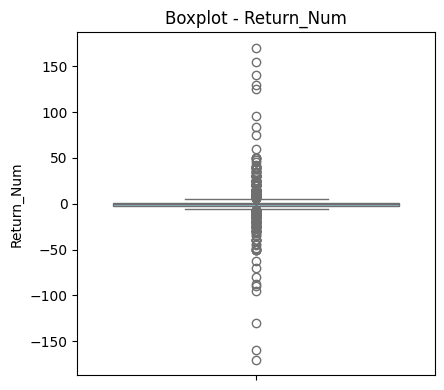

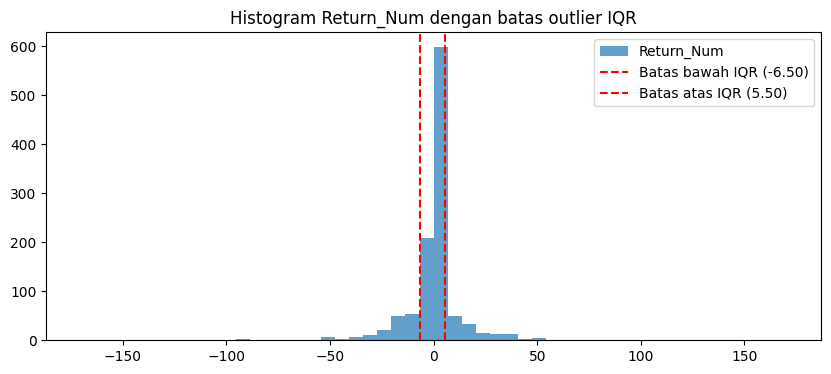

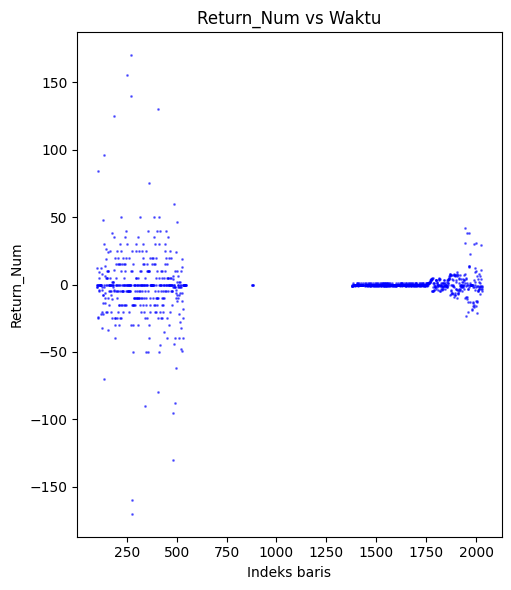

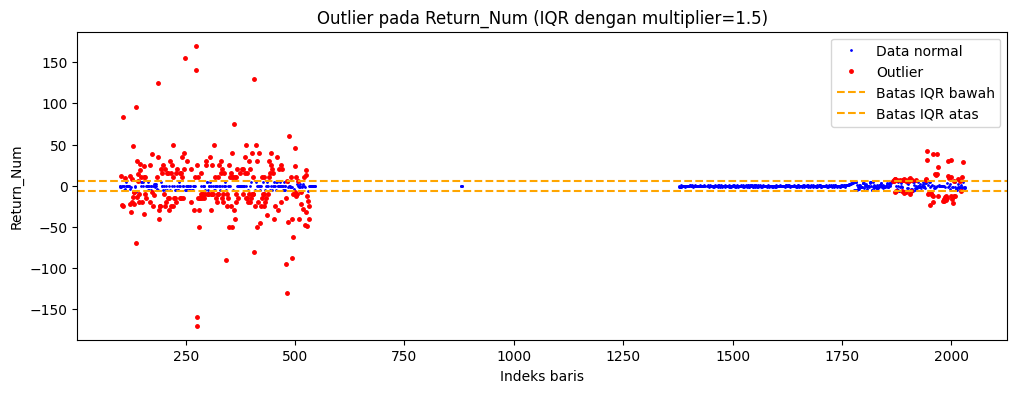

Jumlah outlier pada Return_Num: 305 (27.68% dari data)


In [301]:
selected_columns = ['Return_Num'] 

plt.figure(figsize=(12, 4))
for i, col in enumerate(selected_columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot - {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

for col in selected_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    plt.figure(figsize=(10, 4))
    plt.hist(df[col], bins=50, alpha=0.7, label=col)
    plt.axvline(lower_bound, color='red', linestyle='--', label=f'Batas bawah IQR ({lower_bound:.2f})')
    plt.axvline(upper_bound, color='red', linestyle='--', label=f'Batas atas IQR ({upper_bound:.2f})')
    plt.title(f'Histogram {col} dengan batas outlier IQR')
    plt.legend()
    plt.show()

plt.figure(figsize=(14, 6))
for i, col in enumerate(selected_columns, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df.index, df[col], s=1, alpha=0.5, color='blue')
    plt.title(f'{col} vs Waktu')
    plt.xlabel('Indeks baris')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

for col in selected_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df[col], 'b.', markersize=2, label='Data normal')
    plt.plot(outliers.index, outliers[col], 'r.', markersize=5, label='Outlier')
    plt.axhline(y=lower, color='orange', linestyle='--', label='Batas IQR bawah')
    plt.axhline(y=upper, color='orange', linestyle='--', label='Batas IQR atas')
    plt.title(f'Outlier pada {col} (IQR dengan multiplier=1.5)')
    plt.xlabel('Indeks baris')
    plt.ylabel(col)
    plt.legend()
    plt.show()
    
    print(f"Jumlah outlier pada {col}: {len(outliers)} ({100*len(outliers)/len(df):.2f}% dari data)")

- Volume dan Close: Jelas tidak memiliki outlier (semua titik berada dalam rentang whisker).

- Return: Nilai minimum -0.10 (-10%) secara matematis berada di bawah batas bawah IQR (-0.05), tetapi pada boxplot terlihat whisker memanjang hingga -0.10. Itu berarti plot yang Anda gunakan mungkin menggunakan whisker yang berbeda (misalnya persentil 5-95, atau tidak menggunakan IQR sama sekali). Atau bisa juga data memang memiliki outlier tipis di ekor kiri, tetapi jumlahnya sangat sedikit.

# Distribution Data

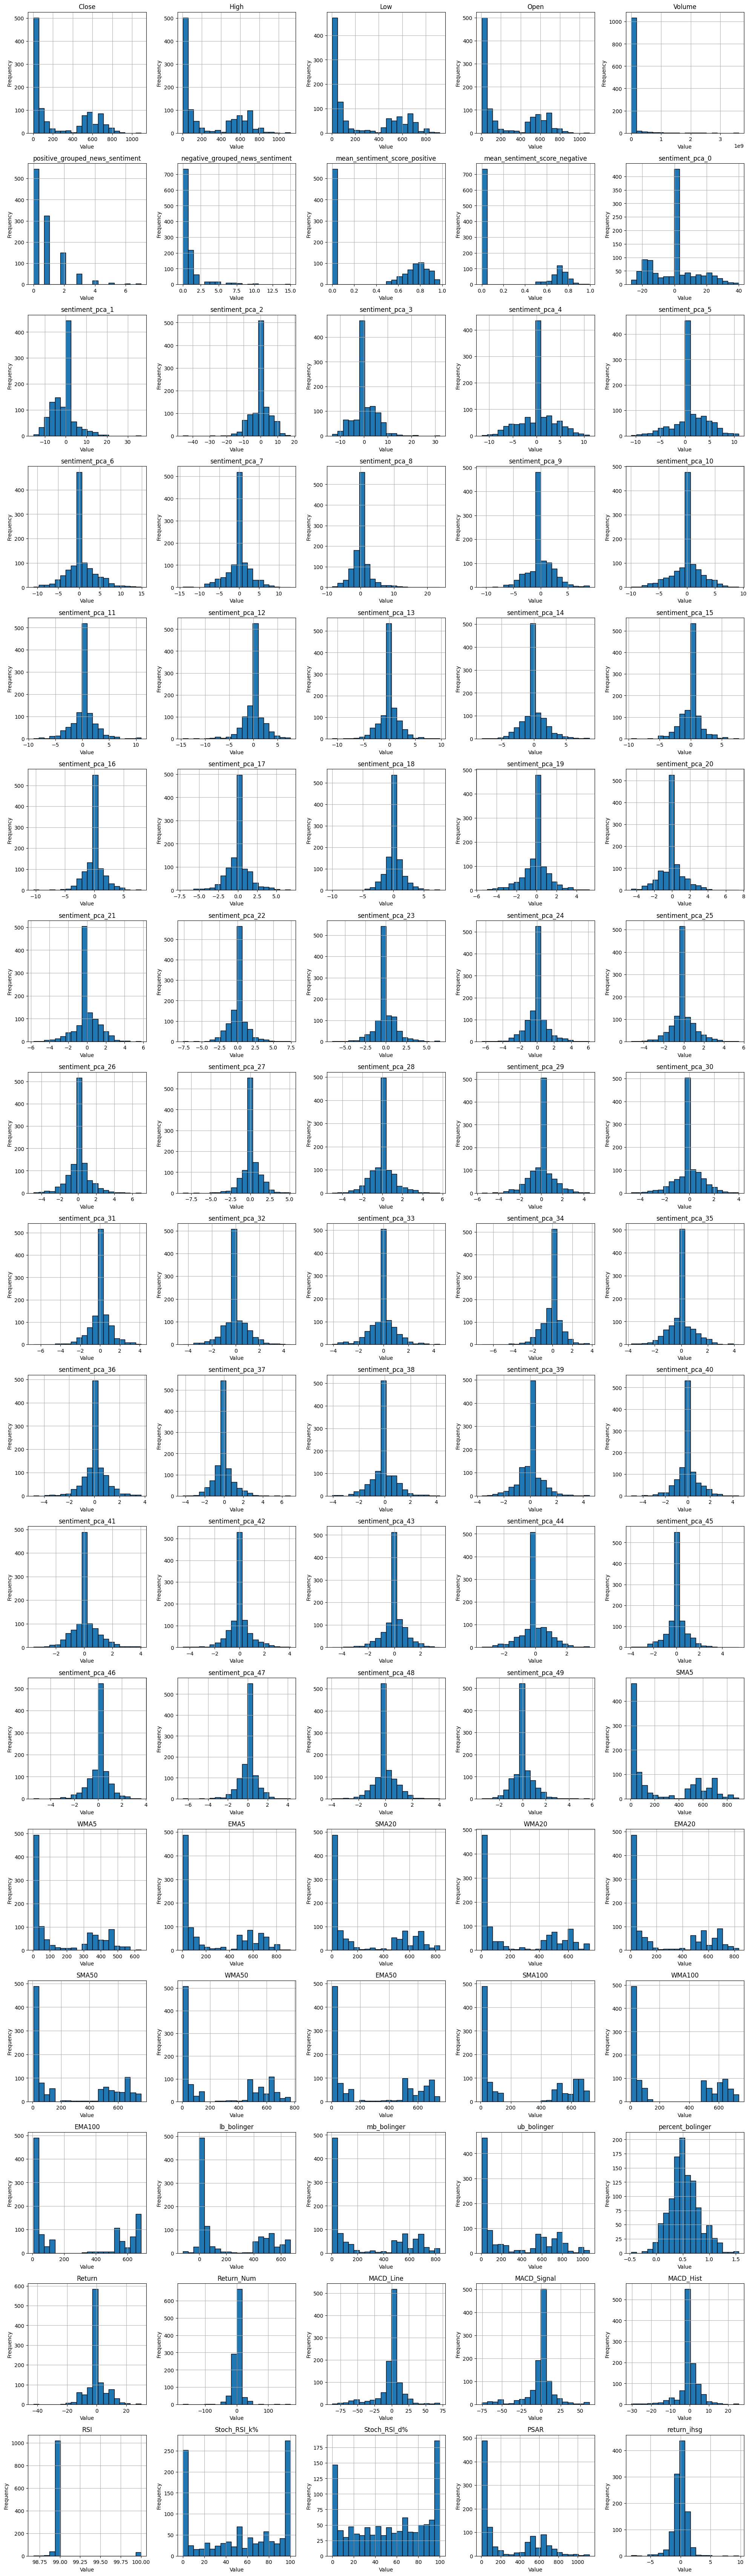

In [302]:
num_vars = df.shape[1]
n_cols = 5
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(df.select_dtypes(include=['number']).columns):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data Correlation

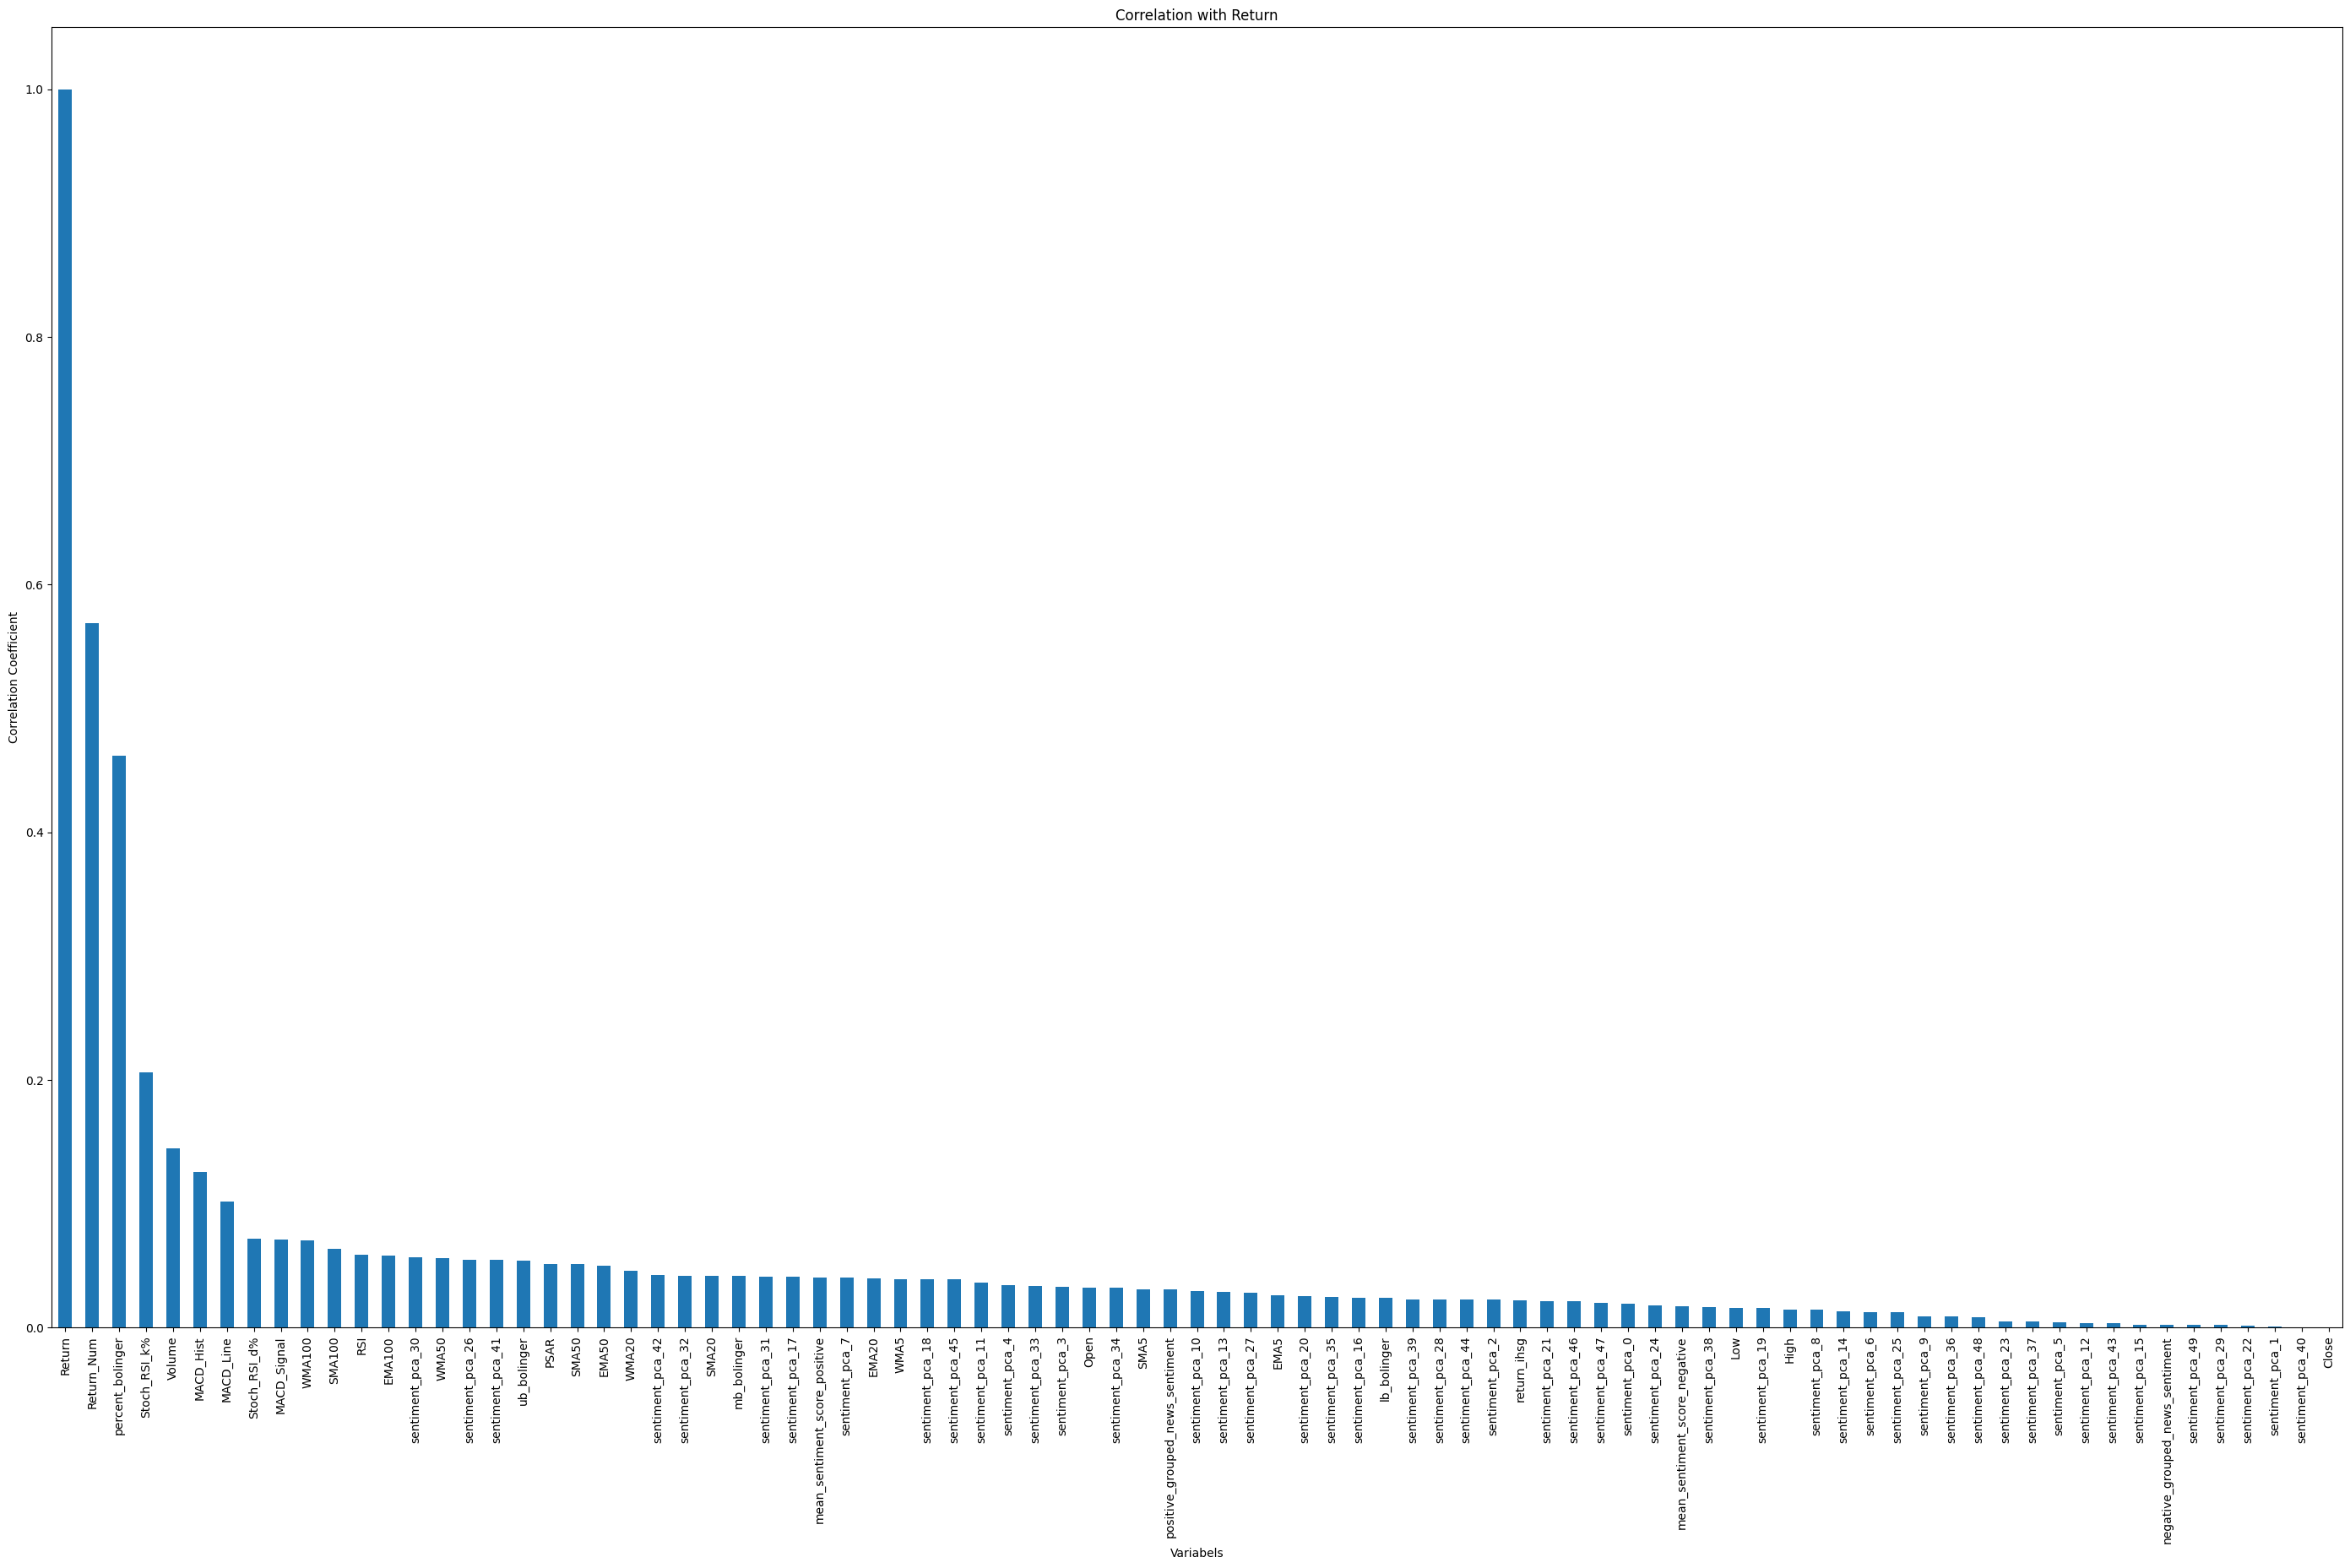

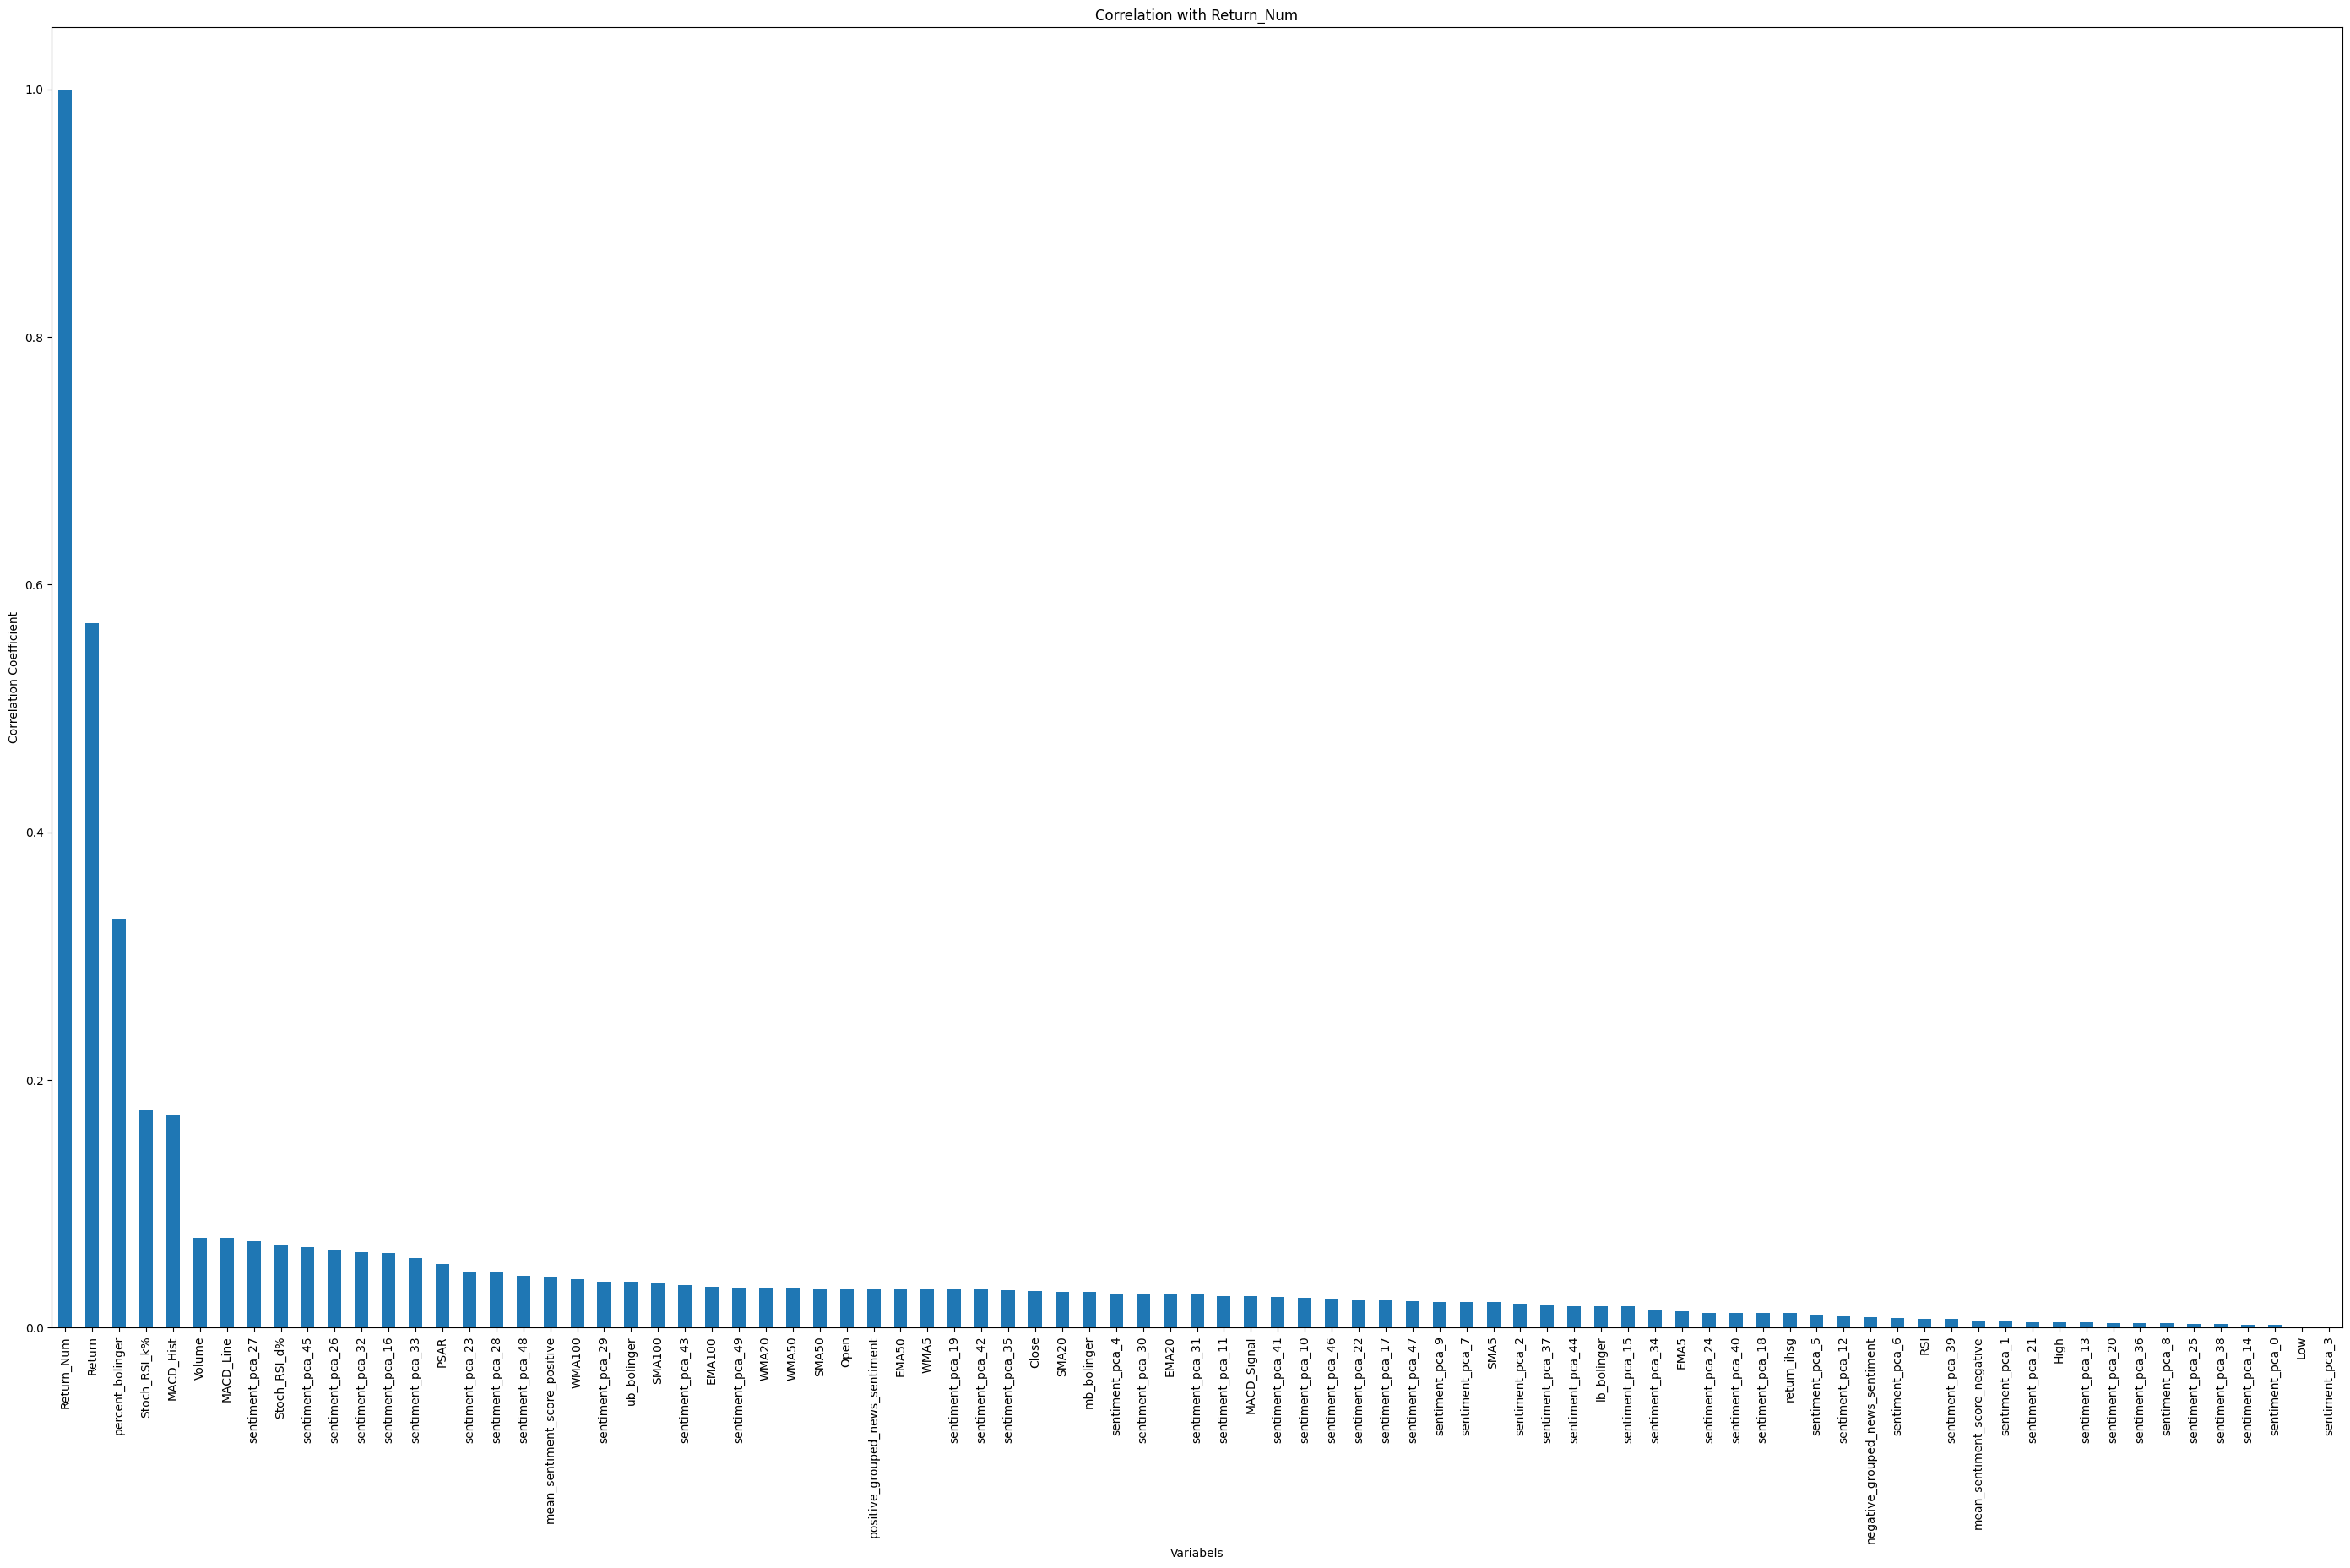

In [303]:
for i in ['Return', 'Return_Num']:
    target_corr = df.select_dtypes(include=['number']).corr()[i]
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)

    plt.figure(figsize=(35, 20))
    target_corr_sorted.plot(kind='bar')
    plt.title(f'Correlation with {i}')
    plt.xlabel('Variabels')
    plt.ylabel('Correlation Coefficient')
plt.show()

## Feature Engineering

In [304]:
features = df.columns.drop(['Date', 'Return', 'Return_Num'])

X = df[features]

y = df['Return']

In [305]:
X

,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,sentiment_pca_0,...,ub_bolinger,percent_bolinger,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
99,460.0,460.0,450.0,452.0,78900,1.0,1.0,0.822121,0.720498,2.498820,...,558.306326,0.100687,-21.126752,-16.986071,-4.140681,98.997214,100.000000,100.000000,535.213266,0.489909
100,460.0,460.0,450.0,452.0,118800,0.0,4.0,0.000000,0.669386,-8.147079,...,557.659353,0.147219,-21.440670,-17.876991,-3.563679,98.997214,100.000000,100.000000,529.500470,1.537435
101,460.0,460.0,450.0,450.0,134700,2.0,0.0,0.685511,0.000000,-10.031882,...,556.429385,0.186653,-21.442279,-18.590048,-2.852231,99.000000,100.000000,100.000000,524.130442,-0.948235
102,472.0,478.0,450.0,460.0,62400,4.0,0.0,0.715043,0.000000,12.213150,...,554.425750,0.312268,-20.241918,-18.920422,-1.321496,98.997813,63.775510,87.925170,519.082615,-0.458010
103,470.0,472.0,462.0,472.0,111000,1.0,1.0,0.912367,0.764113,-6.745322,...,552.318932,0.320453,-19.230332,-18.982404,-0.247927,98.997890,65.049226,76.274912,514.337658,0.520603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027,133.0,151.0,120.0,124.0,3615372200,1.0,3.0,0.588216,0.722465,-15.262874,...,144.687778,0.866541,-2.138448,-7.424987,5.286539,98.966830,0.000000,0.000000,88.049114,-4.286264
2028,128.0,139.0,127.0,133.0,1273985700,2.0,2.0,0.798944,0.785451,-2.495020,...,146.380848,0.792451,-0.360675,-6.012124,5.651450,98.974797,26.402593,8.800864,91.826167,-4.620556
2029,127.0,135.0,125.0,131.0,613176400,3.0,6.0,0.715979,0.672398,-15.941814,...,147.854392,0.767273,0.956506,-4.618398,5.574904,98.979175,40.910980,22.437858,95.376597,7.299092
2030,125.0,134.0,123.0,130.0,612352800,1.0,4.0,0.663087,0.816008,-17.393133,...,148.672222,0.734451,1.818040,-3.331111,5.149151,98.979175,42.465061,36.592878,98.714001,2.673826


In [306]:
y

99     -0.433840
100     0.000000
101     0.000000
102     2.575250
103    -0.424629
          ...   
2027    3.053672
2028   -3.831886
2029   -0.784318
2030   -1.587335
2031   -2.429269
Name: Return, Length: 1102, dtype: float64

Hitung korelasi Pearson antara setiap fitur dan target. Pilih fitur yang nilai absolut korelasinya > 0.1.

- Mengapa threshold 0.3? Karena di bawah itu, hubungan linear sangat lemah fitur seperti Volume_Change biasanya di bawah 0.1 dan cenderung hanya menambah noise.

- Catatan: Korelasi linear tidak menangkap hubungan non-linear, tetapi untuk langkah awal penyaringan cukup baik. Model CNN-LSTM nanti bisa menangkap pola non-linear dari fitur yang tersisa.

# Data Splitting

In [307]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

## Data Normalization

In [308]:
# scaler_X = MinMaxScaler()

# X_scaled = scaler_X.fit_transform(X)

# Data Training

In [309]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Data Predict

In [310]:
pred = model.predict(X_test)

# Data Evaluation

In [311]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE: ", rmse)

RMSE:  6.937816732334183


# Trading Plan

In [312]:
signal = []

for p in pred:
    if p >= 0.01:
        signal.append("BUY")
    elif p <= -0.01:
        signal.append("SELL")
    else:
        signal.append("HOLD")

In [313]:
result = pd.DataFrame({
    "pred_return": pred,
    "signal": signal,
    "price": X_test['Close']
})

print(result.head(20))

      pred_return signal  price
1811    -1.483556   SELL   39.0
1812    -1.453606   SELL   39.0
1813    -0.339413   SELL   42.0
1814     3.242548    BUY   46.0
1815     3.745064    BUY   50.0
1816     6.869265    BUY   55.0
1817     6.519195    BUY   55.0
1818     0.988064    BUY   50.0
1819    -0.336699   SELL   45.0
1820     0.378239    BUY   49.0
1821     0.143957    BUY   48.0
1822     0.104900    BUY   45.0
1823     0.373838    BUY   46.0
1824     1.439834    BUY   46.0
1825     0.296183    BUY   45.0
1826     0.920759    BUY   45.0
1827    -0.069683   SELL   44.0
1828    -1.347669   SELL   42.0
1829    -2.312960   SELL   38.0
1830    -4.537573   SELL   35.0


# Strategy Simulation

In [314]:
data = result.copy()
strategy_return = []

for i in range(len(data)):
    actual_return = data["price"].shift(-1) / data["price"] - 1
    r = actual_return.iloc[i]
    s = data["signal"].iloc[i]

    if s == "BUY":
        strategy_return.append(r)
    elif s == "SELL":
        strategy_return.append(-r)
    else: 
        strategy_return.append(0)
    
data['strategy_return'] = strategy_return
data

,pred_return,signal,price,strategy_return
1811,-1.483556,SELL,39.0,-0.000000
1812,-1.453606,SELL,39.0,-0.076923
1813,-0.339413,SELL,42.0,-0.095238
1814,3.242548,BUY,46.0,0.086957
1815,3.745064,BUY,50.0,0.100000
...,...,...,...,...
2027,3.282182,BUY,133.0,-0.037594
2028,0.792985,BUY,128.0,-0.007812
2029,-0.084948,SELL,127.0,0.015748
2030,-0.063671,SELL,125.0,0.024000


In [315]:
position = 0
entry_price = 0
equity = 100
equity_curve = []

for i in range(len(data)):
    price = data["price"].iloc[i]
    signal = data["signal"].iloc[i]

    if signal == "BUY" and position == 0:
        position = 1
        entry_price = price

    elif signal == "SELL" and position == 1:
        pnl = (price - entry_price) / entry_price
        equity *= (1 + pnl)
        position = 0
        entry_price = 0

    equity_curve.append(equity)

data["strategy_equity"] = equity_curve
data

,pred_return,signal,price,strategy_return,strategy_equity
1811,-1.483556,SELL,39.0,-0.000000,100.000000
1812,-1.453606,SELL,39.0,-0.076923,100.000000
1813,-0.339413,SELL,42.0,-0.095238,100.000000
1814,3.242548,BUY,46.0,0.086957,100.000000
1815,3.745064,BUY,50.0,0.100000,100.000000
...,...,...,...,...,...
2027,3.282182,BUY,133.0,-0.037594,191.413990
2028,0.792985,BUY,128.0,-0.007812,191.413990
2029,-0.084948,SELL,127.0,0.015748,236.015308
2030,-0.063671,SELL,125.0,0.024000,236.015308


In [316]:
data["market_return"] = data["price"].pct_change().shift(-1)
data["market_equity"] = (1 + data["market_return"].fillna(0)).cumprod() * (100)
buy = data[data["signal"] == "BUY"]
sell = data[data["signal"] == "SELL"]

data.dropna(inplace=True)
data

,pred_return,signal,price,strategy_return,strategy_equity,market_return,market_equity
1811,-1.483556,SELL,39.0,-0.000000,100.000000,0.000000,100.000000
1812,-1.453606,SELL,39.0,-0.076923,100.000000,0.076923,107.692308
1813,-0.339413,SELL,42.0,-0.095238,100.000000,0.095238,117.948718
1814,3.242548,BUY,46.0,0.086957,100.000000,0.086957,128.205128
1815,3.745064,BUY,50.0,0.100000,100.000000,0.100000,141.025641
...,...,...,...,...,...,...,...
2026,2.520063,BUY,129.0,0.031008,191.413990,0.031008,341.025641
2027,3.282182,BUY,133.0,-0.037594,191.413990,-0.037594,328.205128
2028,0.792985,BUY,128.0,-0.007812,191.413990,-0.007812,325.641026
2029,-0.084948,SELL,127.0,0.015748,236.015308,-0.015748,320.512821


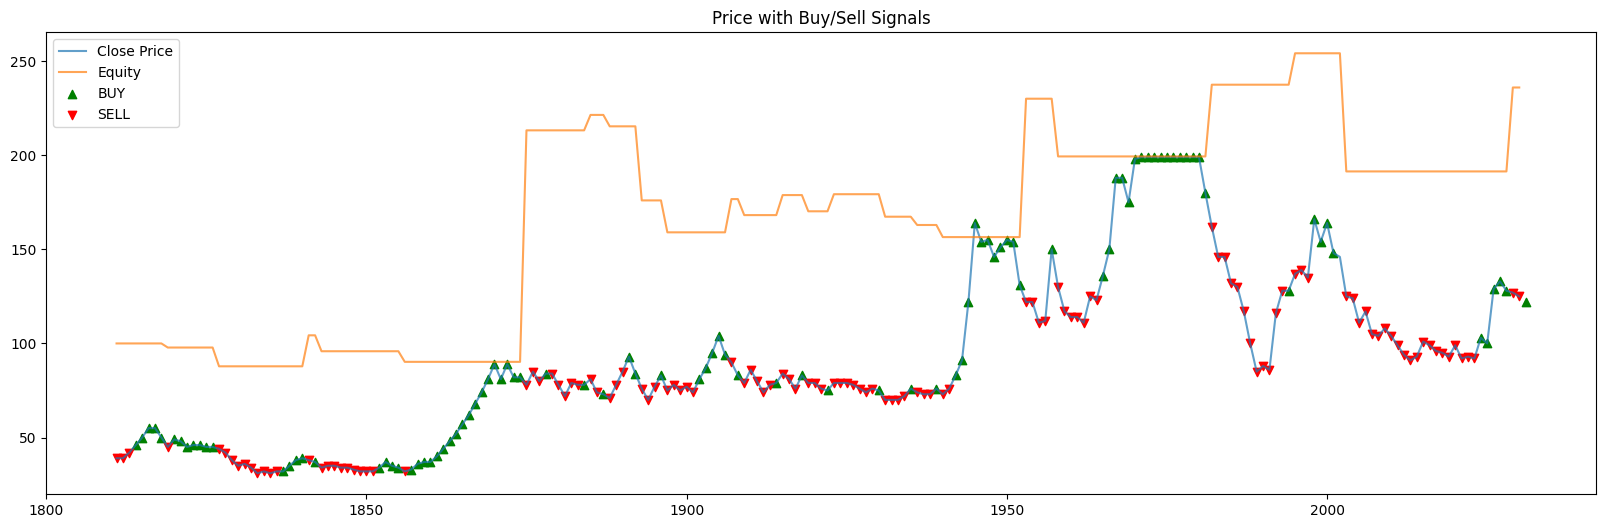

In [317]:
plt.figure(figsize=(20,6))

plt.plot(data["price"], label="Close Price", alpha=0.7)
plt.plot(data["strategy_equity"], label="Equity", alpha=0.7)

plt.scatter(buy.index, buy["price"], label="BUY", marker="^", color="green")
plt.scatter(sell.index, sell["price"], label="SELL", marker="v", color="red")

plt.title("Price with Buy/Sell Signals")
plt.legend()
plt.show()

In [318]:
data["strategy_pnl"] = data["strategy_return"]

print("Total return strategy:", data["strategy_equity"].iloc[-1])
print("Total return market:", data["market_equity"].iloc[-1])
print("Win rate BUY signal:", (data["strategy_return"] > 0).mean())

Total return strategy: 236.01530830119324
Total return market: 312.8205128205123
Win rate BUY signal: 0.45454545454545453


In [319]:
import joblib
from tensorflow.keras.models import save_model

# --- 1. Simpan Model LSTM ---
# Gunakan format .keras untuk menyimpan arsitektur, bobot, dan konfigurasi training.
model.save('model_saham_lstm.keras')
print("Model LSTM berhasil disimpan.")

# --- 2. Simpan Scaler dan Fitur Lainnya dengan Joblib ---
# Scaler untuk fitur input (X)
joblib.dump(scaler_X, 'scaler_X.joblib')
# Scaler untuk target (y)
joblib.dump(scaler_y, 'scaler_y.joblib')
# Daftar nama fitur yang terpilih
joblib.dump(selected_features, 'selected_features.joblib')

print("Scaler dan konfigurasi berhasil disimpan.")

AttributeError: 'RandomForestRegressor' object has no attribute 'save'